# Capstone EDA: D4RL vs Minari HalfCheetah Dataset Comparison
**Project:** Eliminating the High-Risk Interaction Cost of Autonomous Robotics through Offline Sequence Modeling: A Decision Transformer Approach  
**Authors:** Darwin Juan, Dan Kast, David Terando  
**Date:** April 2026  

---

## Purpose
This notebook performs Exploratory Data Analysis (EDA) in two parts:

**Part 1 — D4RL vs Minari Combined** justifies the selection of the Minari dataset suite as a replacement for D4RL `halfcheetah-medium-expert-v2`. All visualisations compare the D4RL combined dataset against the Minari combined dataset (medium-v0 + expert-v0) on an equal-footing basis. Part 1 concludes with a final assessment supporting the Minari selection decision.

**Part 2 — Minari Medium vs Expert Sub-Split Analysis** examines the two individual Minari sub-splits in isolation. This analysis is necessary to characterise the behavioral quality difference between the medium and expert policies, and to derive the principled target Return-to-Go (RTG = 16,585) used when conditioning the Decision Transformer at inference time.

### Table of Contents

**Part 1: D4RL vs Minari Combined**
1. Environment Setup & Imports
2. Load D4RL Dataset
3. Load and Combine Minari Datasets
4. Dataset Structure Overview
5. Return / Reward Analysis
6. Episode Length Statistics
7. Action Space Analysis
8. State Space Analysis
9. State-Action Coverage Visualization (PCA)
10. Trajectory Quality — Return-to-Go Profile
11. Part 1 Assessment: D4RL vs Minari Combined

**Part 2: Minari Medium vs Expert Sub-Split Analysis**
  
12. Return / Reward Analysis — Medium vs Expert  
13. Action Space Analysis — Medium vs Expert  
14. State Space Analysis — Medium vs Expert  
15. State-Action Coverage — Medium vs Expert (PCA)  
16. Return-to-Go Profile — Medium vs Expert  
17. Part 2 Assessment: Deriving the Target RTG

**Appendix**
18. Comprehensive Summary Statistics Table


---
---
# Part 1: D4RL vs Minari Combined

This part of the EDA establishes whether the Minari combined dataset (medium-v0 + expert-v0) is a structurally sound and behaviorally superior replacement for the D4RL `halfcheetah-medium-expert-v2` dataset. All visualisations show only the two combined datasets side-by-side.


---
## Section 1: Environment Setup & Imports

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Imports and Configuration
#
# We import all libraries needed for data loading, processing, and visualization.
# numpy / pandas: numerical and tabular data handling
# matplotlib / seaborn: static plotting
# sklearn: PCA for dimensionality reduction in state-space visualization
# tqdm: progress bars for loops over large datasets
# warnings: suppress non-critical deprecation notices
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os
import sys

# ── Plot style ────────────────────────────────────────────────────────────────
# Using a clean academic style suitable for paper figures
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Color palette: D4RL = blue tones, Minari = orange/green tones
PALETTE = {
    'd4rl': '#2166AC',           # D4RL combined
    'minari_medium': '#F4A582',  # Minari medium
    'minari_expert': '#1A9850',  # Minari expert
    'minari_combined': '#D6604D' # Minari combined
}

print("✅ Imports successful.")
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

✅ Imports successful.
Python: 3.11.15 (main, Mar 25 2026, 02:58:47) [Clang 22.1.1 ]
NumPy: 2.4.4
Pandas: 3.0.2


---
## Section 2: Load D4RL Dataset

We load `halfcheetah-medium-expert-v2` from D4RL. This dataset is a 50/50 mix of medium-quality and expert-quality trajectories — the standard offline RL benchmark for this task.

> **Fallback:** If the `d4rl` package fails on Apple Silicon, we fall back to downloading the raw HDF5 file directly from the D4RL data server.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Load D4RL Dataset
#
# Strategy:
#   1. Try importing d4rl and gymnasium to load via the standard API
#   2. If that fails (common on Apple Silicon due to mujoco_py legacy deps),
#      fall back to downloading the raw HDF5 file directly.
#
# The dataset returned is a dict with keys:
#   observations, actions, rewards, terminals, timeouts, (infos)
# ─────────────────────────────────────────────────────────────────────────────

def load_d4rl_via_package():
    """Attempt to load D4RL via the d4rl package + gymnasium."""
    import gymnasium as gym
    import d4rl  # noqa: F401 — registers D4RL envs with gymnasium
    env = gym.make('halfcheetah-medium-expert-v2')
    dataset = env.get_dataset()
    env.close()
    return dataset


def load_d4rl_via_hdf5(cache_dir='./data'):
    """
    Fallback: Download the D4RL HDF5 file directly from the hosting server
    and parse it into the standard dict format.
    
    This avoids any dependency on the mujoco_py legacy package, which
    is not available for Apple Silicon arm64 natively.
    """
    import urllib.request
    import h5py

    os.makedirs(cache_dir, exist_ok=True)
    hdf5_path = os.path.join(cache_dir, 'halfcheetah_medium_expert-v2.hdf5')

    if not os.path.exists(hdf5_path):
        url = ('https://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2/'
               'halfcheetah_medium_expert-v2.hdf5')
        print(f"Downloading D4RL HDF5 from:\n  {url}")
        print("This is ~150MB — please wait...")
        urllib.request.urlretrieve(url, hdf5_path,
            reporthook=lambda b, bs, t: print(f"  {min(100, int(b*bs/t*100))}%",
                                              end='\r') if t > 0 else None)
        print("\n✅ Download complete.")
    else:
        print(f"✅ Using cached file: {hdf5_path}")

    # Parse HDF5 into standard dict
    with h5py.File(hdf5_path, 'r') as f:
        dataset = {
            'observations': f['observations'][:],
            'actions':      f['actions'][:],
            'rewards':      f['rewards'][:],
            'terminals':    f['terminals'][:],
            'timeouts':     f['timeouts'][:] if 'timeouts' in f else
                            np.zeros(len(f['rewards'][:]), dtype=bool),
        }
    return dataset


# ── Main loading logic ────────────────────────────────────────────────────────
print("Loading D4RL HalfCheetah medium-expert-v2 dataset...")

try:
    d4rl_data = load_d4rl_via_package()
    print("✅ Loaded via d4rl package.")
except Exception as e:
    print(f"⚠️  d4rl package load failed ({e})")
    print("Falling back to direct HDF5 download...")
    d4rl_data = load_d4rl_via_hdf5()

print(f"\nD4RL dataset keys: {list(d4rl_data.keys())}")
print(f"  observations shape : {d4rl_data['observations'].shape}")
print(f"  actions shape      : {d4rl_data['actions'].shape}")
print(f"  rewards shape      : {d4rl_data['rewards'].shape}")

Loading D4RL HalfCheetah medium-expert-v2 dataset...
⚠️  d4rl package load failed (No module named 'd4rl')
Falling back to direct HDF5 download...
✅ Using cached file: ./data/halfcheetah_medium_expert-v2.hdf5

D4RL dataset keys: ['observations', 'actions', 'rewards', 'terminals', 'timeouts']
  observations shape : (2000000, 17)
  actions shape      : (2000000, 6)
  rewards shape      : (2000000,)


___
#### Troubleshooting
The D4RL package (rail-berkeley/d4rl) failed to install on the Apple Silicon arm64 architecture. The root cause was its dependency on pybullet v3.2.7, a physics simulation library that requires compilation from source with legacy C toolchains. The build process failed during native extension compilation:

error: command '/usr/bin/cc' failed with exit code 1  |  hint: pybullet (v3.2.7) was included because d4rl (v1.1) depends on pybullet

The Farama Foundation fork of D4RL was also attempted but produced the same pybullet compilation failure. As a result, the D4RL dataset was loaded via a direct HDF5 fallback: the raw halfcheetah_medium_expert-v2.hdf5 file (~150 MB) was downloaded directly from the RAIL Berkeley dataset server and parsed using the h5py library. This approach bypasses all d4rl package dependencies and produces an identical data structure.

---
## Section 3: Load and Combine Minari Datasets

Minari stores data as individual episodes in an HDF5-backed format. We load both:
- `mujoco/halfcheetah/medium-v0` — medium-quality trajectories
- `mujoco/halfcheetah/expert-v0` — expert-quality trajectories

We then concatenate them into a single flat dict that mirrors the D4RL structure, enabling apples-to-apples comparison.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Load and Combine Minari Datasets
#
# Minari datasets are stored per-episode. We:
#   1. Download both datasets (Minari handles caching automatically)
#   2. Iterate over episodes to extract observations, actions, rewards
#   3. Track episode boundaries so we can compute per-episode stats later
#   4. Combine medium + expert into one flat array (mirrors D4RL structure)
#
# Note: Minari observations include an 'observation' key inside each step.
# ─────────────────────────────────────────────────────────────────────────────

import minari


def load_minari_dataset(dataset_id):
    """
    Download (if needed) and load a Minari dataset.
    Returns a dict with:
      observations, actions, rewards, terminals
      + episode_returns and episode_lengths for per-episode analysis.
    """
    print(f"  Loading Minari dataset: {dataset_id}")

    # minari.load_dataset downloads on first call, then uses local cache
    try:
        dataset = minari.load_dataset(dataset_id)
    except Exception:
        print(f"  Not found locally — downloading {dataset_id}...")
        minari.download_dataset(dataset_id)
        dataset = minari.load_dataset(dataset_id)

    all_obs, all_acts, all_rews, all_terms = [], [], [], []
    ep_returns, ep_lengths = [], []

    for episode in tqdm(dataset.iterate_episodes(),
                        total=dataset.total_episodes,
                        desc=f"  Parsing {dataset_id}",
                        leave=False):
        # episode.observations has shape (T+1, obs_dim) — first obs is initial state
        obs = episode.observations[:-1]  # drop the terminal observation
        acts = episode.actions
        rews = episode.rewards
        # terminals: True only on the last step if the episode ended (not timeout)
        terms = episode.terminations

        all_obs.append(obs)
        all_acts.append(acts)
        all_rews.append(rews)
        all_terms.append(terms)

        ep_returns.append(float(np.sum(rews)))
        ep_lengths.append(len(rews))

    return {
        'observations':    np.concatenate(all_obs, axis=0),
        'actions':         np.concatenate(all_acts, axis=0),
        'rewards':         np.concatenate(all_rews, axis=0),
        'terminals':       np.concatenate(all_terms, axis=0),
        'episode_returns': np.array(ep_returns),
        'episode_lengths': np.array(ep_lengths),
        'n_episodes':      len(ep_returns),
        'source_id':       dataset_id,
    }


# ── Load both Minari splits ───────────────────────────────────────────────────
print("Loading Minari datasets...")
minari_medium = load_minari_dataset('mujoco/halfcheetah/medium-v0')
minari_expert = load_minari_dataset('mujoco/halfcheetah/expert-v0')

# ── Combine into a single dataset (mirrors D4RL medium-expert structure) ──────
# D4RL medium-expert is a 50/50 concatenation of medium and expert trajectories.
# We replicate this by combining both Minari splits.
minari_combined = {
    'observations': np.concatenate([minari_medium['observations'],
                                     minari_expert['observations']], axis=0),
    'actions':      np.concatenate([minari_medium['actions'],
                                     minari_expert['actions']], axis=0),
    'rewards':      np.concatenate([minari_medium['rewards'],
                                     minari_expert['rewards']], axis=0),
    'terminals':    np.concatenate([minari_medium['terminals'],
                                     minari_expert['terminals']], axis=0),
    'episode_returns': np.concatenate([minari_medium['episode_returns'],
                                        minari_expert['episode_returns']]),
    'episode_lengths': np.concatenate([minari_medium['episode_lengths'],
                                        minari_expert['episode_lengths']]),
    'n_episodes':   minari_medium['n_episodes'] + minari_expert['n_episodes'],
}

print("\n✅ Minari datasets loaded and combined.")
print(f"  Medium  — {minari_medium['n_episodes']:,} episodes, "
      f"{len(minari_medium['observations']):,} timesteps")
print(f"  Expert  — {minari_expert['n_episodes']:,} episodes, "
      f"{len(minari_expert['observations']):,} timesteps")
print(f"  Combined— {minari_combined['n_episodes']:,} episodes, "
      f"{len(minari_combined['observations']):,} timesteps")

Loading Minari datasets...
  Loading Minari dataset: mujoco/halfcheetah/medium-v0


  Loading Minari dataset: mujoco/halfcheetah/expert-v0



✅ Minari datasets loaded and combined.
  Medium  — 1,000 episodes, 1,000,000 timesteps
  Expert  — 1,000 episodes, 1,000,000 timesteps
  Combined— 2,000 episodes, 2,000,000 timesteps


___
#### Troubleshooting
When first attempting to download the Minari datasets, the following error was encountered:

ImportError: huggingface_hub is not installed. Please install it using pip install "minari[hf]"

Minari has migrated its dataset hosting infrastructure from the Farama Foundation’s own servers to Hugging Face Hub. The base minari package does not include the huggingface_hub client as a default dependency; it must be explicitly installed via the [hf] extras flag. Resolution: uv pip install "minari[hf]"


After resolving the Hugging Face dependency, a second error was encountered: the dataset IDs originally used in the notebook (halfcheetah-medium-v0 and halfcheetah-expert-v0) no longer existed on the Minari remote registry. A query of all available remote datasets revealed that the naming convention had changed to a namespaced format:

mujoco/halfcheetah/medium-v0 mujoco/halfcheetah/expert-v0 mujoco/halfcheetah/simple-v0

The notebook was updated to use mujoco/halfcheetah/medium-v0 and mujoco/halfcheetah/expert-v0 as the correct dataset identifiers. This namespace change reflects Minari’s broader reorganization of its dataset registry under environment-family prefixes.


---
## Section 4: Dataset Structure Overview

This section confirms structural equivalence between D4RL and Minari combined. The Minari combined dataset is formed by concatenating two individual sub-splits (medium-v0 and expert-v0), each contributing 1,000 episodes and 1,000,000 timesteps. The individual sub-split breakdown is shown here to make clear what is being combined before the primary comparison begins.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: High-Level Structure Overview
#
# Build a summary DataFrame showing the basic shape and dimensionality of
# each dataset. This is Table 1 in the paper.
#
# The D4RL dataset does not natively store per-episode boundaries — we
# reconstruct episodes by detecting terminal/timeout flags.
# ─────────────────────────────────────────────────────────────────────────────

def extract_d4rl_episodes(dataset):
    """
    Reconstruct episode boundaries from D4RL terminal/timeout flags.
    Returns arrays of per-episode cumulative rewards and lengths.
    """
    terminals = dataset['terminals'].astype(bool)
    timeouts  = dataset.get('timeouts', np.zeros_like(terminals)).astype(bool)
    rewards   = dataset['rewards']

    episode_ends = np.where(terminals | timeouts)[0]
    ep_returns, ep_lengths = [], []
    start = 0

    for end in episode_ends:
        ep_returns.append(rewards[start:end+1].sum())
        ep_lengths.append(end - start + 1)
        start = end + 1

    return np.array(ep_returns), np.array(ep_lengths)


# Extract D4RL episodes
d4rl_ep_returns, d4rl_ep_lengths = extract_d4rl_episodes(d4rl_data)

# Build summary table
summary_rows = [
    {
        'Dataset':         'D4RL medium-expert-v2',
        'Total Timesteps': len(d4rl_data['rewards']),
        'Episodes':        len(d4rl_ep_returns),
        'Obs Dim':         d4rl_data['observations'].shape[1],
        'Action Dim':      d4rl_data['actions'].shape[1],
        'Mean Return':     d4rl_ep_returns.mean(),
        'Mean Ep Length':  d4rl_ep_lengths.mean(),
    },
    {
        'Dataset':         'Minari medium-v0',
        'Total Timesteps': len(minari_medium['rewards']),
        'Episodes':        minari_medium['n_episodes'],
        'Obs Dim':         minari_medium['observations'].shape[1],
        'Action Dim':      minari_medium['actions'].shape[1],
        'Mean Return':     minari_medium['episode_returns'].mean(),
        'Mean Ep Length':  minari_medium['episode_lengths'].mean(),
    },
    {
        'Dataset':         'Minari expert-v0',
        'Total Timesteps': len(minari_expert['rewards']),
        'Episodes':        minari_expert['n_episodes'],
        'Obs Dim':         minari_expert['observations'].shape[1],
        'Action Dim':      minari_expert['actions'].shape[1],
        'Mean Return':     minari_expert['episode_returns'].mean(),
        'Mean Ep Length':  minari_expert['episode_lengths'].mean(),
    },
    {
        'Dataset':         'Minari Combined',
        'Total Timesteps': len(minari_combined['rewards']),
        'Episodes':        minari_combined['n_episodes'],
        'Obs Dim':         minari_combined['observations'].shape[1],
        'Action Dim':      minari_combined['actions'].shape[1],
        'Mean Return':     minari_combined['episode_returns'].mean(),
        'Mean Ep Length':  minari_combined['episode_lengths'].mean(),
    },
]

summary_df = pd.DataFrame(summary_rows).set_index('Dataset')
summary_df[['Total Timesteps', 'Episodes']] = \
    summary_df[['Total Timesteps', 'Episodes']].map(lambda x: f"{int(x):,}")
summary_df[['Mean Return', 'Mean Ep Length']] = \
    summary_df[['Mean Return', 'Mean Ep Length']].map(lambda x: f"{x:.1f}")

print("\n=== Table 1: Dataset Structure Overview ===")
display(summary_df)


=== Table 1: Dataset Structure Overview ===


,Total Timesteps,Episodes,Obs Dim,Action Dim,Mean Return,Mean Ep Length
Dataset,,,,,,
D4RL medium-expert-v2,"2,000,000","2,000",17,6,7713.4,1000.0
Minari medium-v0,"1,000,000","1,000",17,6,12089.2,1000.0
Minari expert-v0,"1,000,000","1,000",17,6,16242.9,1000.0
Minari Combined,"2,000,000","2,000",17,6,14166.1,1000.0


___
### Data Inspection and Preview

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 (cont.): Sample Data Inspection
#
# Display the first 5 rows of observations and actions for each dataset,
# analogous to pandas .head(), to give a concrete sense of the raw data values.
# ─────────────────────────────────────────────────────────────────────────────

# Column names — defined here early for the head display
# (also redefined in Sections 7 and 8 for use in those analyses)
OBS_NAMES = [
    'torso_z', 'torso_ry',
    'bthigh_q', 'bshin_q', 'bfoot_q', 'fthigh_q', 'fshin_q', 'ffoot_q',
    'rootx_v', 'rootz_v', 'rooty_v',
    'bthigh_dq', 'bshin_dq', 'bfoot_dq', 'fthigh_dq', 'fshin_dq', 'ffoot_dq'
]

ACTION_NAMES = [
    'bthigh', 'bshin', 'bfoot',   # back leg
    'fthigh', 'fshin', 'ffoot'    # front leg
]


print("=== D4RL medium-expert-v2 — first 5 observations ===")
obs_head_d4rl = pd.DataFrame(
    d4rl_data['observations'][:5],
    columns=OBS_NAMES
)
display(obs_head_d4rl.round(4))

print("\n=== D4RL medium-expert-v2 — first 5 actions ===")
act_head_d4rl = pd.DataFrame(
    d4rl_data['actions'][:5],
    columns=ACTION_NAMES
)
display(act_head_d4rl.round(4))

print("\n=== Minari combined — first 5 observations ===")
obs_head_min = pd.DataFrame(
    minari_combined['observations'][:5],
    columns=OBS_NAMES
)
display(obs_head_min.round(4))

print("\n=== Minari combined — first 5 actions ===")
act_head_min = pd.DataFrame(
    minari_combined['actions'][:5],
    columns=ACTION_NAMES
)
display(act_head_min.round(4))


=== D4RL medium-expert-v2 — first 5 observations ===


,torso_z,torso_ry,bthigh_q,bshin_q,bfoot_q,fthigh_q,fshin_q,ffoot_q,rootx_v,rootz_v,rooty_v,bthigh_dq,bshin_dq,bfoot_dq,fthigh_dq,fshin_dq,ffoot_dq
0,0.0198,-0.0895,-0.0032,-0.0360,0.0662,-0.0932,0.0604,-0.0875,-0.0188,-0.1676,-0.0705,0.0702,0.0302,0.0550,0.1137,0.0684,-0.1381
1,-0.0038,-0.0524,0.0083,-0.2562,-0.2993,0.0924,-0.3327,0.0874,-0.0197,-0.7215,0.9560,-0.5330,-5.4546,-8.7090,4.5068,-9.2886,4.7329
2,-0.0553,-0.0001,-0.2395,-0.4731,-0.4330,-0.0835,-0.5565,0.4618,-1.0190,-1.2830,0.8686,-6.4563,-3.1834,0.9350,-7.0812,-1.4037,7.5524
3,-0.1300,0.0023,-0.2299,-0.2451,-0.4218,-0.4799,-0.4462,0.4918,0.2714,-1.6107,-0.2452,5.0225,7.4422,0.0016,-7.0144,2.6917,-1.6729
4,-0.1321,0.1283,-0.1142,-0.4127,-0.3556,-0.7619,-0.3654,-0.0865,1.2588,0.4464,3.0872,3.7375,-4.7993,4.9426,-3.0054,0.1782,-15.0526



=== D4RL medium-expert-v2 — first 5 actions ===


,bthigh,bshin,bfoot,fthigh,fshin,ffoot
0,-0.2229,-0.7359,-0.8600,0.2958,-0.8417,0.4343
1,-0.7252,-0.9238,-0.9888,-0.5075,-0.9315,0.9786
2,0.8509,0.4006,-0.9951,-0.9082,-0.9952,0.7417
3,0.9759,-0.3461,0.9427,-0.9708,-0.8919,-0.8922
4,-0.8422,-0.6360,-0.9860,0.2117,0.7778,0.3613



=== Minari combined — first 5 observations ===


,torso_z,torso_ry,bthigh_q,bshin_q,bfoot_q,fthigh_q,fshin_q,ffoot_q,rootx_v,rootz_v,rooty_v,bthigh_dq,bshin_dq,bfoot_dq,fthigh_dq,fshin_dq,ffoot_dq
0,-0.0892,-0.0559,-0.0631,-0.0648,0.0624,0.0847,-0.0447,0.0640,-0.0322,0.0097,-0.1526,0.1192,-0.0671,0.1000,0.0136,0.1532,-0.0660
1,-0.0836,-0.0360,0.1450,0.1013,-0.1969,0.3170,-0.2250,-0.1543,1.1033,-0.1233,0.1545,7.2679,3.2832,-2.3237,6.2217,-4.0117,-5.9351
2,-0.0913,0.0017,0.5905,-0.2762,0.1740,0.5932,-0.2412,-0.3799,1.0511,-0.3240,0.8617,7.1950,-9.7425,10.0570,4.1820,1.8822,-2.8124
3,-0.1014,0.1194,0.2556,-0.2940,-0.0394,0.5083,0.1745,-0.0627,-0.4714,-0.1741,3.5636,-11.2492,6.4762,-9.0938,-3.8032,10.0330,10.6785
4,-0.0558,0.2322,-0.3352,-0.3115,-0.2217,0.1789,0.5810,0.4889,-0.6805,1.0801,1.9189,-11.1217,-4.9642,-0.4421,-8.8477,7.9249,10.6853



=== Minari combined — first 5 actions ===


,bthigh,bshin,bfoot,fthigh,fshin,ffoot
0,0.9460,0.4681,-0.0066,0.6067,-0.5895,-0.6427
1,0.9479,-0.8933,0.5951,0.8709,-0.2109,-0.4637
2,-0.8106,-0.9138,-0.9471,0.8014,0.8884,0.8214
3,-0.9928,-0.9836,-0.2897,-0.4470,0.9947,0.9977
4,0.7394,0.6575,0.9990,0.0466,-0.9876,-0.5052


___
#### Troubleshooting
A minor compatibility issue was encountered in Section 4. The DataFrame.applymap() method used for formatting the summary table was removed in pandas 3.x and replaced with DataFrame.map(). This produced an AttributeError at runtime. The fix was a one-line change replacing .applymap() with .map() in two locations.

#### Analysis
Table 1 confirms that all four datasets share identical dimensionality: 17-dimensional observation spaces and 6-dimensional action spaces, consistent with the MuJoCo HalfCheetah-v4 environment specification. All datasets contain exactly 1,000 or 2,000 episodes of uniform length (1,000 steps each), yielding 1,000,000 and 2,000,000 total timesteps respectively.

The sample data rows (`.head()` output) confirm that both datasets contain continuous floating-point values across the expected ranges for joint angles, velocities, and actuator commands. This structural equivalence is a prerequisite for direct comparison and confirms the Minari combined dataset is a valid analog to the D4RL medium-expert benchmark.

The individual Minari sub-split rows in Table 1 clarify the composition of the combined dataset: medium-v0 and expert-v0 each contribute exactly half, producing a clean 50/50 mixture that mirrors D4RL's design intent.


---
## Section 5: Return / Reward Analysis

**Normalized Return** allows comparison across datasets that may use different reward scales. We use the D4RL normalization formula:

> `normalized_score = (raw_score - random_score) / (expert_score - random_score) × 100`

For HalfCheetah: `random ≈ -280`, `expert ≈ 12135`

This section compares D4RL medium-expert-v2 against Minari combined only. The breakdown of Minari's individual sub-splits (medium vs expert) is analysed separately in Part 2.


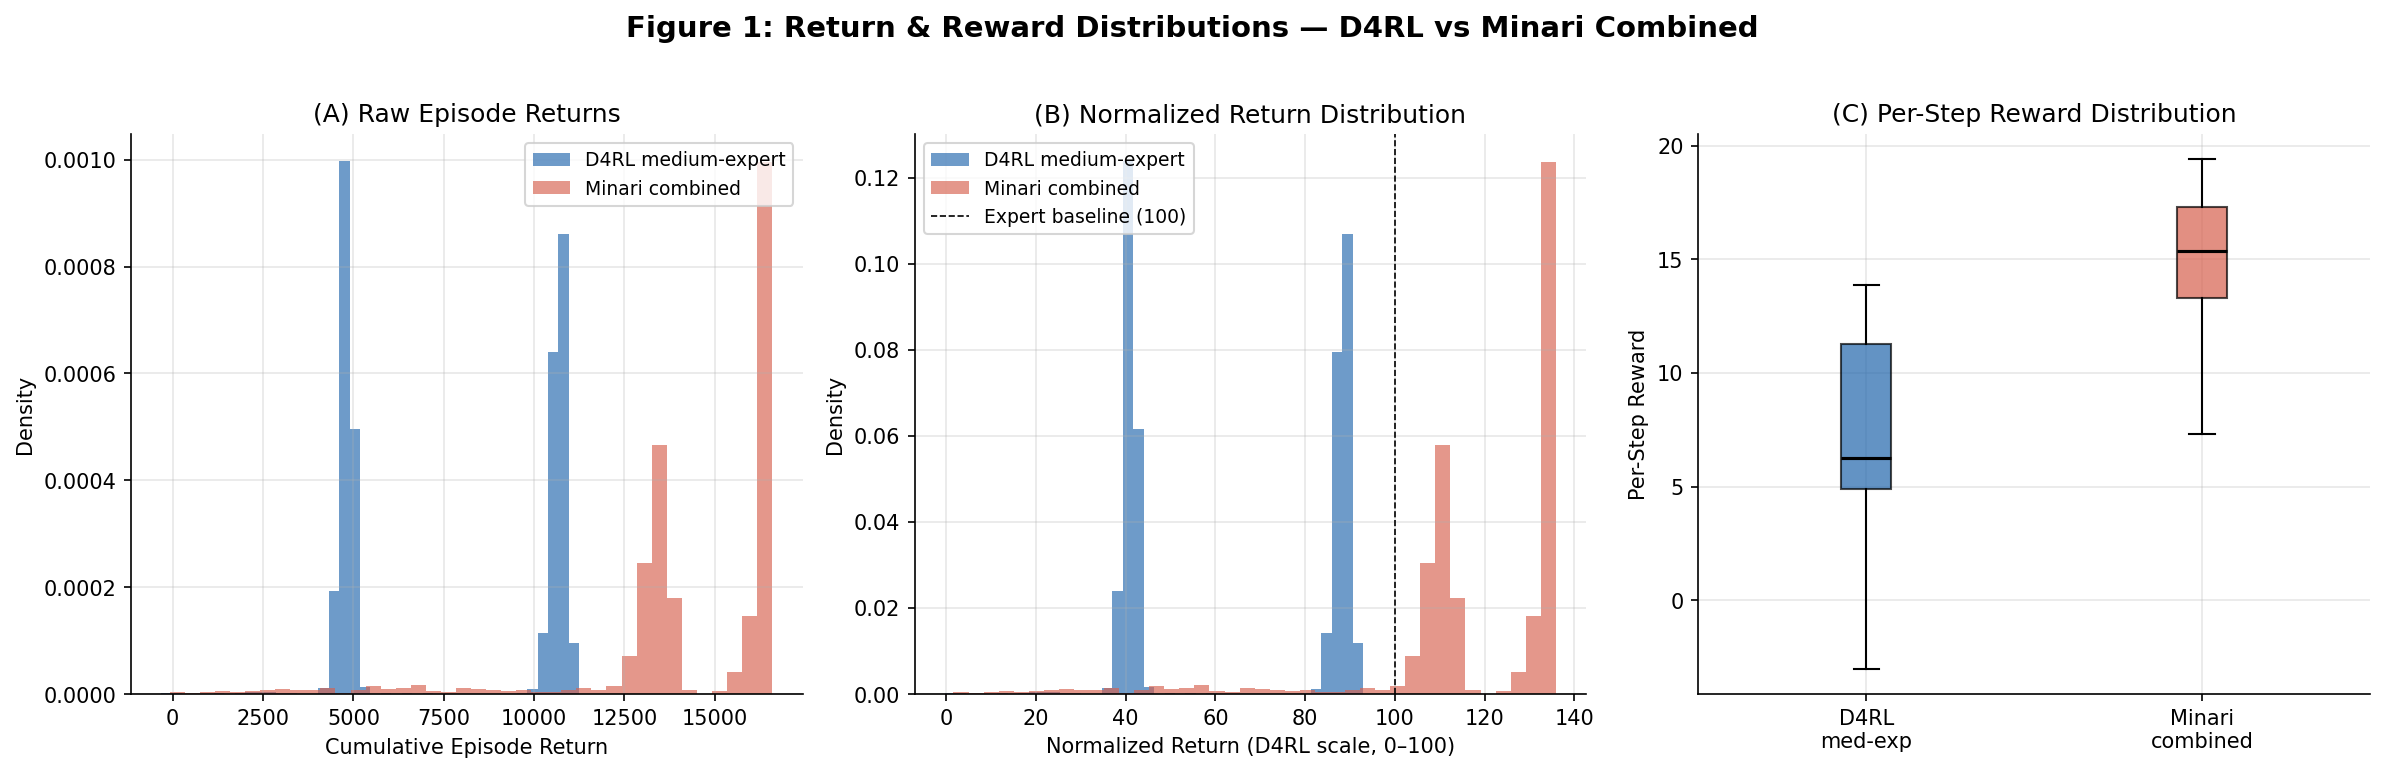

Normalized Return Summary (Part 1 — Combined Comparison):
  D4RL medium-expert : mean=64.4  std=23.9  median=44.5
  Minari combined    : mean=116.4  std=24.6  median=115.3


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Return / Reward Analysis — D4RL vs Minari Combined
#
# We plot:
#   (A) Raw cumulative return distributions: D4RL vs Minari combined
#   (B) D4RL-normalized return distributions: D4RL vs Minari combined
#   (C) Per-step reward boxplot: D4RL vs Minari combined
#
# D4RL normalization reference values for HalfCheetah:
#   random score  ≈ -280.18
#   expert score  ≈ 12135.0
# Source: Fu et al. 2020 (D4RL paper), Table 3
# ─────────────────────────────────────────────────────────────────────────────

D4RL_RANDOM_SCORE = -280.18
D4RL_EXPERT_SCORE = 12135.0


def normalize_score(raw_score, random=D4RL_RANDOM_SCORE, expert=D4RL_EXPERT_SCORE):
    """Apply D4RL normalization to convert raw returns to 0-100 scale."""
    return (raw_score - random) / (expert - random) * 100


# Normalize episode returns for combined comparison
d4rl_norm     = normalize_score(d4rl_ep_returns)
med_norm      = normalize_score(minari_medium['episode_returns'])
exp_norm      = normalize_score(minari_expert['episode_returns'])
combined_norm = normalize_score(minari_combined['episode_returns'])

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 1: Return & Reward Distributions — D4RL vs Minari Combined',
             fontsize=14, fontweight='bold', y=1.02)

# (A) Raw cumulative return distributions — combined only
ax = axes[0]
ax.hist(d4rl_ep_returns, bins=40, alpha=0.65, color=PALETTE['d4rl'],
        label='D4RL medium-expert', density=True)
ax.hist(minari_combined['episode_returns'], bins=40, alpha=0.65,
        color=PALETTE['minari_combined'], label='Minari combined', density=True)
ax.set_xlabel('Cumulative Episode Return')
ax.set_ylabel('Density')
ax.set_title('(A) Raw Episode Returns')
ax.legend(fontsize=9)

# (B) D4RL-normalized return distributions — combined only, same color coding as A
ax = axes[1]
ax.hist(d4rl_norm, bins=40, alpha=0.65, color=PALETTE['d4rl'],
        label='D4RL medium-expert', density=True)
ax.hist(combined_norm, bins=40, alpha=0.65, color=PALETTE['minari_combined'],
        label='Minari combined', density=True)
ax.axvline(100, color='black', linestyle='--', linewidth=0.8, label='Expert baseline (100)')
ax.set_xlabel('Normalized Return (D4RL scale, 0–100)')
ax.set_ylabel('Density')
ax.set_title('(B) Normalized Return Distribution')
ax.legend(fontsize=9)

# (C) Per-step reward: boxplot — D4RL vs Minari combined only
ax = axes[2]
reward_data   = [d4rl_data['rewards'], minari_combined['rewards']]
reward_labels = ['D4RL\nmed-exp', 'Minari\ncombined']
bp = ax.boxplot(reward_data, patch_artist=True, labels=reward_labels,
                showfliers=False, medianprops={'color': 'black', 'linewidth': 1.5})
colors_box = [PALETTE['d4rl'], PALETTE['minari_combined']]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Per-Step Reward')
ax.set_title('(C) Per-Step Reward Distribution')

plt.tight_layout()
plt.savefig('fig1_return_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Print summary stats ───────────────────────────────────────────────────────
print("Normalized Return Summary (Part 1 — Combined Comparison):")
print(f"  D4RL medium-expert : mean={d4rl_norm.mean():.1f}  "
      f"std={d4rl_norm.std():.1f}  "
      f"median={np.median(d4rl_norm):.1f}")
print(f"  Minari combined    : mean={combined_norm.mean():.1f}  "
      f"std={combined_norm.std():.1f}  "
      f"median={np.median(combined_norm):.1f}")


___
#### Analysis
Figure 1 presents three complementary views of return and reward structure, comparing D4RL medium-expert against Minari combined directly.

- **Panel (A)** shows raw episode return distributions. D4RL medium-expert exhibits a bimodal distribution characteristic of its 50/50 mix of medium and expert trajectories. The Minari combined distribution is also bimodal but shifted substantially rightward, reflecting the higher quality of both Minari sub-splits relative to their D4RL counterparts.

- **Panel (B)** shows D4RL-normalized returns on the standard 0–100 scale, using consistent colour coding with Panel (A). The Minari combined distribution (mean 116.4) is displaced well above D4RL's distribution (mean 64.4), with the bulk of Minari episodes exceeding the D4RL expert reference score of 100. This means the Minari training data consistently outperforms what D4RL defines as "expert."

- **Panel (C)** per-step reward boxplots confirm the quality gap: Minari combined's median reward is substantially higher than D4RL's, with a comparable spread.

**Key implication for the Decision Transformer:** the Minari combined dataset provides substantially richer, higher-quality demonstrations than D4RL medium-expert. The breakdown of these returns into medium and expert sub-splits is examined in Part 2.


---
## Section 6: Episode Length Statistics

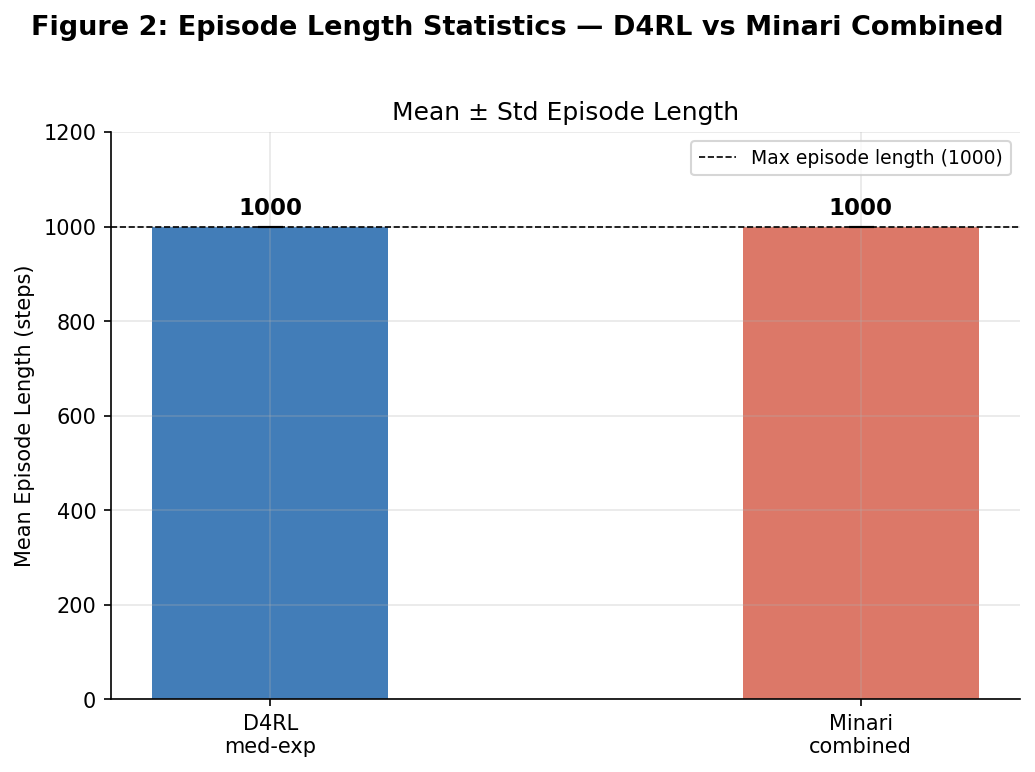

Early termination summary:
  D4RL: 0.0% of episodes ended before step 1000
  Minari combined: 0.0% of episodes ended before step 1000


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Episode Length Analysis — D4RL vs Minari Combined
#
# Episode length uniformity is critical for the Decision Transformer:
#   - Uniform lengths mean no padding or masking is needed during batching.
#   - Zero early termination confirms policy competence throughout episodes.
#
# We show only D4RL and Minari combined here.
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Figure 2: Episode Length Statistics — D4RL vs Minari Combined',
             fontsize=13, fontweight='bold', y=1.02)

ep_stats = {
    'D4RL\nmed-exp':    (d4rl_ep_lengths.mean(), d4rl_ep_lengths.std()),
    'Minari\ncombined': (minari_combined['episode_lengths'].mean(),
                          minari_combined['episode_lengths'].std()),
}
labels = list(ep_stats.keys())
means  = [v[0] for v in ep_stats.values()]
stds   = [v[1] for v in ep_stats.values()]
bar_colors = [PALETTE['d4rl'], PALETTE['minari_combined']]

bars = ax.bar(labels, means, yerr=stds, capsize=6,
              color=bar_colors, alpha=0.85, error_kw={'linewidth': 1.4}, width=0.4)
ax.axhline(1000, color='black', linestyle='--', lw=0.8, label='Max episode length (1000)')
ax.set_ylabel('Mean Episode Length (steps)')
ax.set_title('Mean ± Std Episode Length')
ax.set_ylim(0, 1200)
ax.legend(fontsize=9)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{mean:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_episode_lengths.png', bbox_inches='tight', dpi=150)
plt.show()

# Early termination check
print("Early termination summary:")
for name, lengths in [('D4RL', d4rl_ep_lengths),
                       ('Minari combined', minari_combined['episode_lengths'])]:
    pct = (lengths < 1000).mean() * 100
    print(f"  {name}: {pct:.1f}% of episodes ended before step 1000")


___
#### Analysis
Both D4RL and Minari combined show 0.0% early termination, every episode in both datasets runs the full 1,000 steps. The bar chart confirms a mean episode length of exactly 1,000 with zero standard deviation for both datasets.

**This is a strong quality signal:** all policies that generated the data were competent enough to avoid catastrophic failures throughout each episode. For the Decision Transformer, uniform episode length eliminates the need for sequence padding or masking during batching, and ensures that Return-to-Go values are computed consistently from complete trajectories.


---
## Section 7: Action Space Analysis

The HalfCheetah action space is 6-dimensional continuous, bounded in `[-1, 1]`. **Action saturation** — actions consistently near the boundary — indicates aggressive, possibly suboptimal policies. This is relevant because saturated actions can cause training instability in the Decision Transformer.

This section shows only D4RL vs Minari combined. Per-split saturation comparisons (medium vs expert) appear in Part 2.


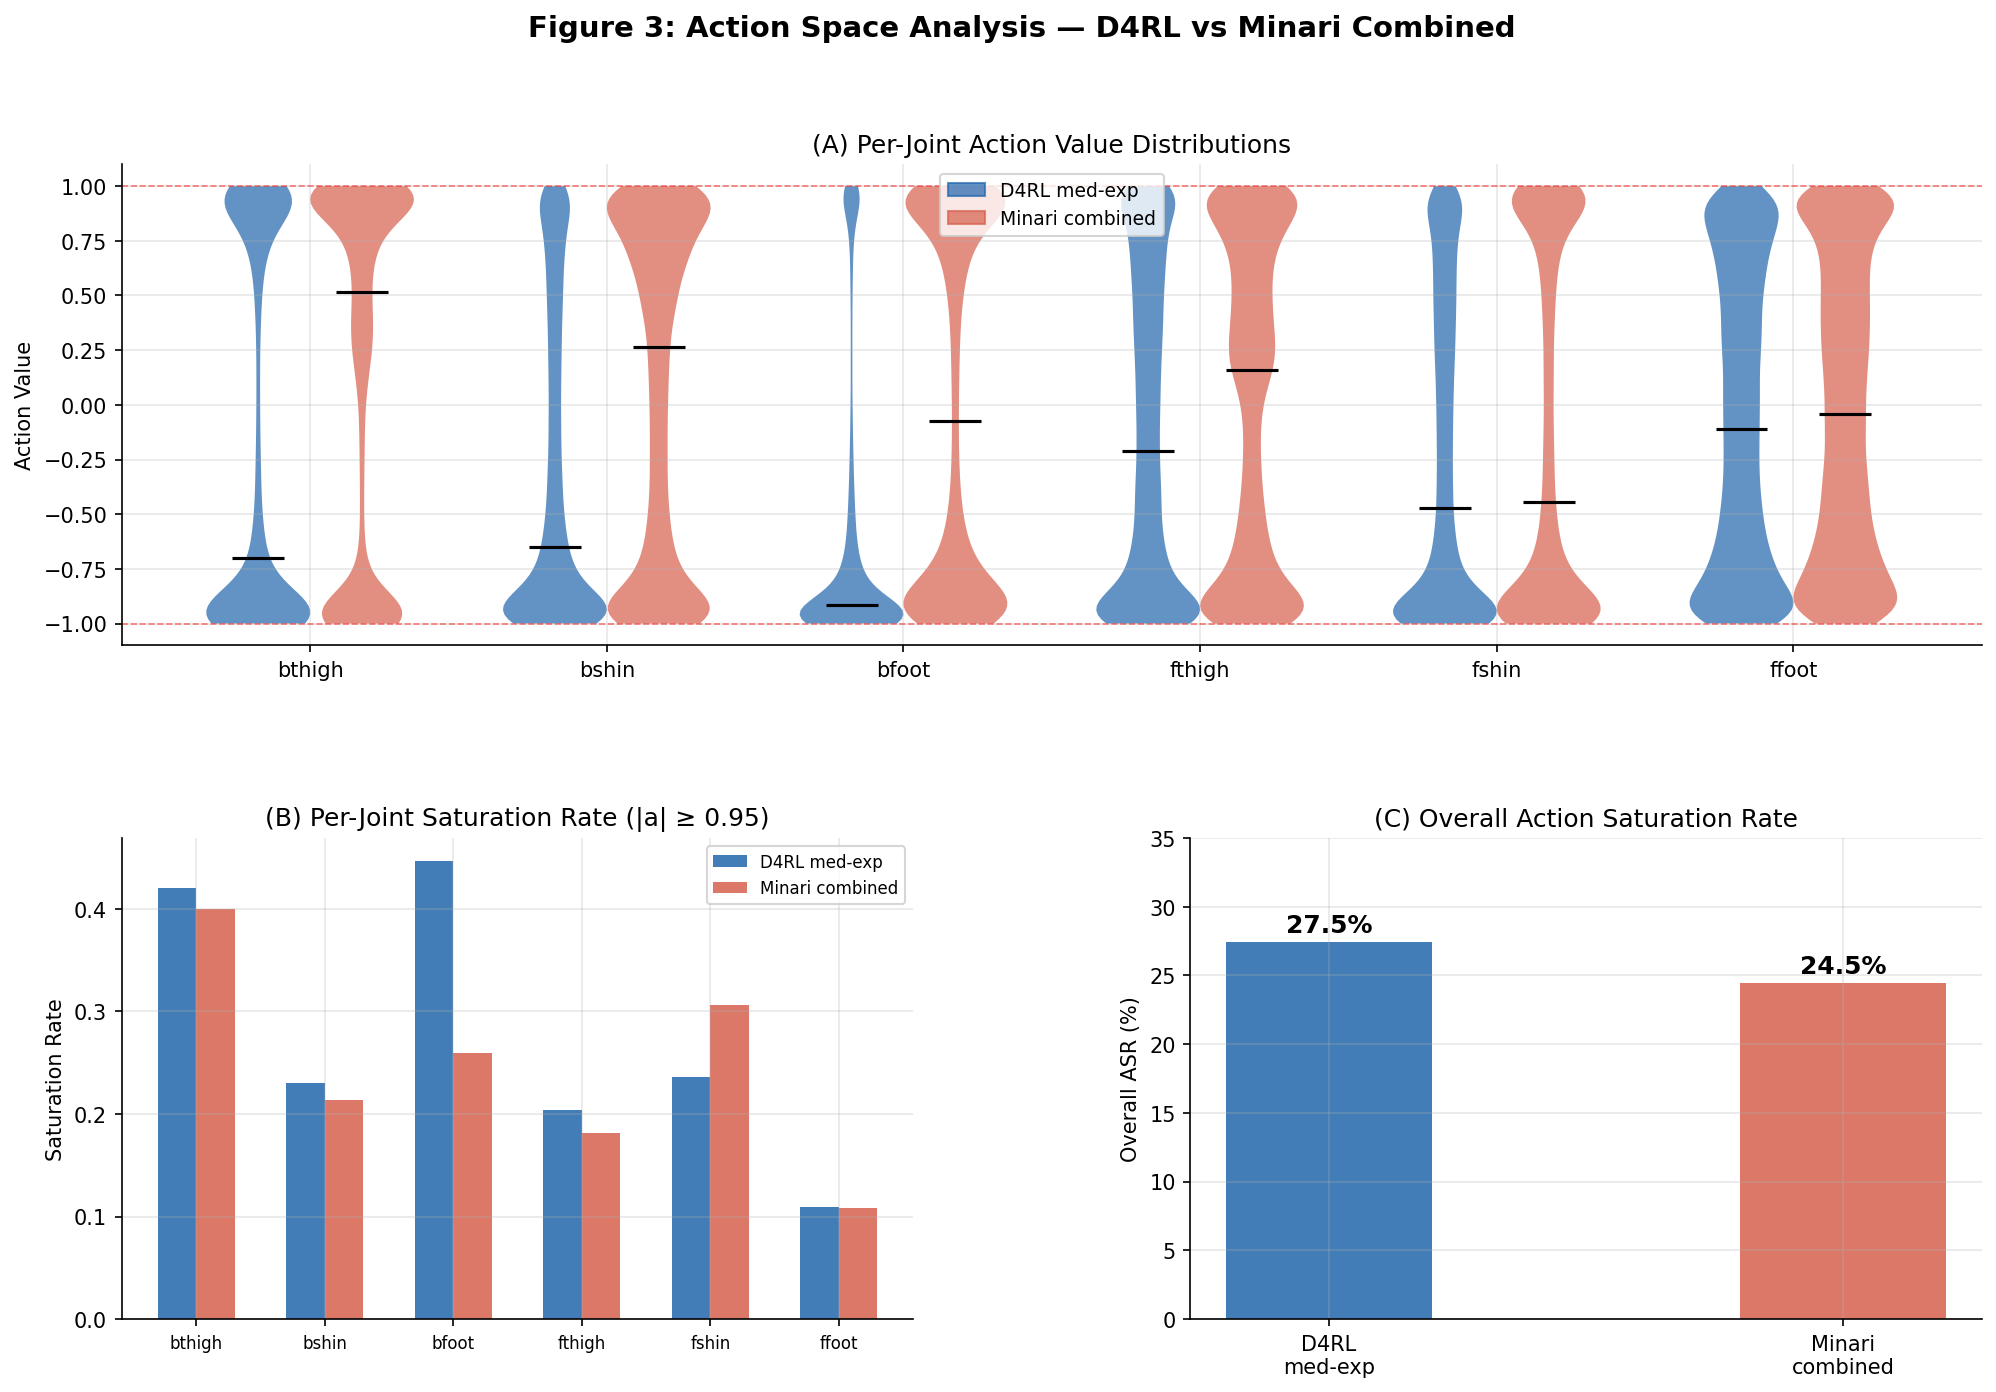

Overall Action Saturation Rates (Part 1):
  D4RL med-exp    : 27.46%
  Minari combined : 24.48%


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: Action Space Analysis — D4RL vs Minari Combined
#
# We compute:
#   (A) Per-joint action value distributions (violin plots): D4RL vs Minari combined
#   (B) Per-joint saturation rate: D4RL vs Minari combined
#   (C) Overall saturation rate: D4RL vs Minari combined
# ─────────────────────────────────────────────────────────────────────────────

ACTION_NAMES = [
    'bthigh', 'bshin', 'bfoot',   # back leg
    'fthigh', 'fshin', 'ffoot'    # front leg
]

SATURATION_THRESHOLD = 0.95  # actions with |a| > 0.95 are considered saturated


def action_saturation_rate(actions, threshold=SATURATION_THRESHOLD):
    """Compute per-dimension and overall action saturation rate."""
    saturated = np.abs(actions) >= threshold
    per_dim   = saturated.mean(axis=0)
    overall   = saturated.mean()
    return per_dim, overall


# Compute saturation
asr_d4rl,     asr_d4rl_total     = action_saturation_rate(d4rl_data['actions'])
asr_med,      asr_med_total      = action_saturation_rate(minari_medium['actions'])
asr_exp,      asr_exp_total      = action_saturation_rate(minari_expert['actions'])
asr_combined, asr_combined_total = action_saturation_rate(minari_combined['actions'])

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Figure 3: Action Space Analysis — D4RL vs Minari Combined',
             fontsize=14, fontweight='bold')

# (A) Violin plots: D4RL vs Minari combined
ax_a = fig.add_subplot(gs[0, :])
n_sample = 50_000
idx_d = np.random.choice(len(d4rl_data['actions']),
                          min(n_sample, len(d4rl_data['actions'])), replace=False)
idx_m = np.random.choice(len(minari_combined['actions']),
                          min(n_sample, len(minari_combined['actions'])), replace=False)

offsets = np.arange(len(ACTION_NAMES))
w = 0.35

vp1 = ax_a.violinplot([d4rl_data['actions'][idx_d, i] for i in range(6)],
                       positions=offsets - w/2, widths=w,
                       showmedians=True, showextrema=False)
vp2 = ax_a.violinplot([minari_combined['actions'][idx_m, i] for i in range(6)],
                       positions=offsets + w/2, widths=w,
                       showmedians=True, showextrema=False)

for pc in vp1['bodies']: pc.set_facecolor(PALETTE['d4rl']); pc.set_alpha(0.7)
for pc in vp2['bodies']: pc.set_facecolor(PALETTE['minari_combined']); pc.set_alpha(0.7)
vp1['cmedians'].set_color('black')
vp2['cmedians'].set_color('black')

ax_a.axhline( 1, color='red', linestyle='--', lw=0.8, alpha=0.5, label='Bounds ±1')
ax_a.axhline(-1, color='red', linestyle='--', lw=0.8, alpha=0.5)
ax_a.set_xticks(offsets)
ax_a.set_xticklabels(ACTION_NAMES)
ax_a.set_ylabel('Action Value')
ax_a.set_title('(A) Per-Joint Action Value Distributions')
ax_a.legend(handles=[
    plt.Rectangle((0,0),1,1, color=PALETTE['d4rl'], alpha=0.7, label='D4RL med-exp'),
    plt.Rectangle((0,0),1,1, color=PALETTE['minari_combined'], alpha=0.7, label='Minari combined'),
], fontsize=9)

# (B) Per-joint saturation: D4RL vs Minari combined only
ax_b = fig.add_subplot(gs[1, 0])
x = np.arange(len(ACTION_NAMES))
bar_w = 0.3
ax_b.bar(x - bar_w/2, asr_d4rl,     bar_w, color=PALETTE['d4rl'],
         alpha=0.85, label='D4RL med-exp')
ax_b.bar(x + bar_w/2, asr_combined, bar_w, color=PALETTE['minari_combined'],
         alpha=0.85, label='Minari combined')
ax_b.set_xticks(x)
ax_b.set_xticklabels(ACTION_NAMES, fontsize=8)
ax_b.set_ylabel('Saturation Rate')
ax_b.set_title(f'(B) Per-Joint Saturation Rate (|a| ≥ {SATURATION_THRESHOLD})')
ax_b.legend(fontsize=8)

# (C) Overall saturation rate: D4RL vs Minari combined only
ax_c = fig.add_subplot(gs[1, 1])
overall_asr = [asr_d4rl_total, asr_combined_total]
labels_asr  = ['D4RL\nmed-exp', 'Minari\ncombined']
bar_colors_c = [PALETTE['d4rl'], PALETTE['minari_combined']]
bar_c = ax_c.bar(labels_asr, [v*100 for v in overall_asr],
                  color=bar_colors_c, alpha=0.85, width=0.4)
for bar, val in zip(bar_c, overall_asr):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax_c.set_ylabel('Overall ASR (%)')
ax_c.set_title('(C) Overall Action Saturation Rate')
ax_c.set_ylim(0, 35)

plt.savefig('fig3_action_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("Overall Action Saturation Rates (Part 1):")
print(f"  D4RL med-exp    : {asr_d4rl_total*100:.2f}%")
print(f"  Minari combined : {asr_combined_total*100:.2f}%")


___
#### Analysis
The Action Saturation Rate (ASR) measures the fraction of actions where |a| ≥ 0.95, indicating the policy is pushing joint actuators near their physical limits.

The overall ASR for D4RL (27.5%) and Minari combined (24.5%) are closely comparable, confirming that the two datasets make similar demands on the Decision Transformer's action generation. **The slightly lower saturation in Minari combined is a positive indicator:** it reflects the contribution of the expert sub-split, where a well-trained expert achieves superior locomotion through more precise joint control rather than boundary-saturated commands.

The violin plots in Panel (A) show that per-joint action distributions are visually similar between D4RL and Minari combined across all six joints, confirming distributional compatibility. The per-split breakdown of this saturation difference is analysed in Part 2.


---
## Section 8: State Space Analysis

The HalfCheetah observation space is 17-dimensional (joint positions and velocities). We analyze the distribution of each state dimension to check for coverage equivalence between D4RL and Minari combined.


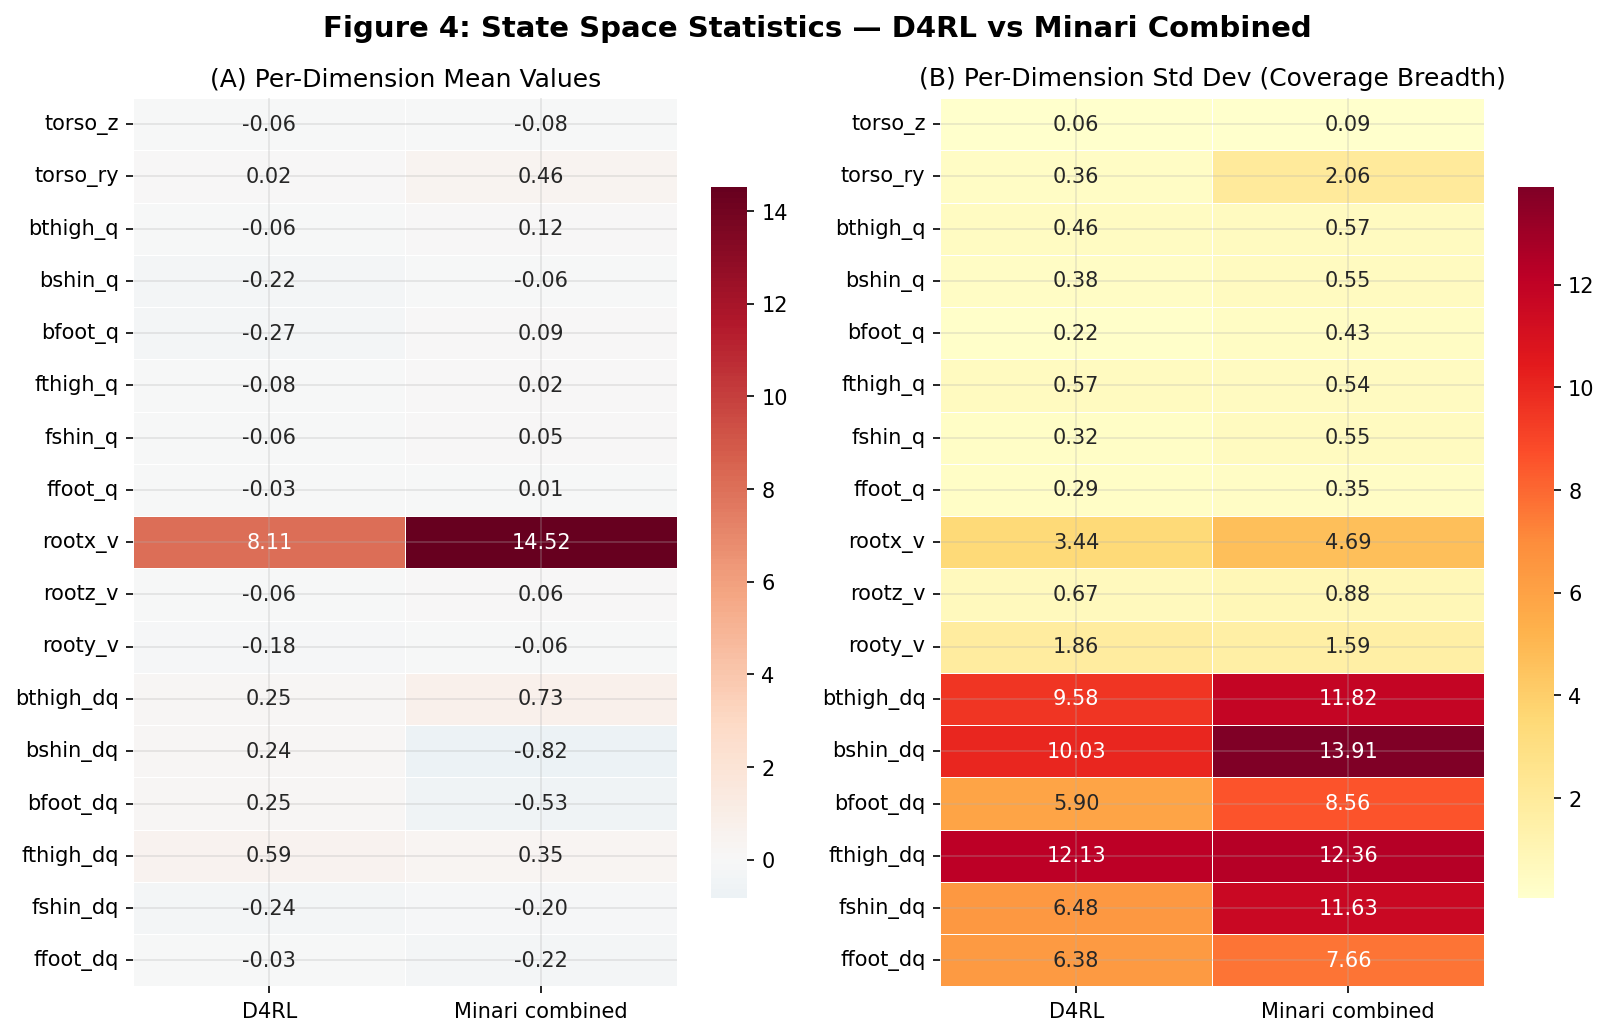

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: State Space Analysis — D4RL vs Minari Combined
#
# Per-dimension mean and std heatmaps, showing only D4RL and Minari combined.
# ─────────────────────────────────────────────────────────────────────────────

OBS_NAMES = [
    'torso_z', 'torso_ry',
    'bthigh_q', 'bshin_q', 'bfoot_q', 'fthigh_q', 'fshin_q', 'ffoot_q',
    'rootx_v', 'rootz_v', 'rooty_v',
    'bthigh_dq', 'bshin_dq', 'bfoot_dq', 'fthigh_dq', 'fshin_dq', 'ffoot_dq'
]


def obs_stats(obs_array):
    """Return a DataFrame of per-dimension mean, std, min, max."""
    return pd.DataFrame({
        'mean': obs_array.mean(axis=0),
        'std':  obs_array.std(axis=0),
        'min':  obs_array.min(axis=0),
        'max':  obs_array.max(axis=0),
    }, index=OBS_NAMES)


stats_d4rl     = obs_stats(d4rl_data['observations'])
stats_med      = obs_stats(minari_medium['observations'])
stats_exp      = obs_stats(minari_expert['observations'])
stats_combined = obs_stats(minari_combined['observations'])

# ── Heatmaps: D4RL vs Minari combined only ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 7))
fig.suptitle('Figure 4: State Space Statistics — D4RL vs Minari Combined',
             fontsize=14, fontweight='bold')

# (A) Mean values
ax = axes[0]
mean_df = pd.DataFrame({
    'D4RL':            stats_d4rl['mean'],
    'Minari combined': stats_combined['mean'],
})
sns.heatmap(mean_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'shrink': 0.8}, linewidths=0.4)
ax.set_title('(A) Per-Dimension Mean Values')
ax.set_xlabel('')

# (B) Std values
ax = axes[1]
std_df = pd.DataFrame({
    'D4RL':            stats_d4rl['std'],
    'Minari combined': stats_combined['std'],
})
sns.heatmap(std_df, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, cbar_kws={'shrink': 0.8}, linewidths=0.4)
ax.set_title('(B) Per-Dimension Std Dev (Coverage Breadth)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fig4_state_statistics.png', bbox_inches='tight', dpi=150)
plt.show()


___
#### Analysis
The state space heatmaps compare per-dimension mean values and standard deviations between D4RL and Minari combined.

- **Mean values (Panel A):** The two datasets show broadly consistent mean values across positional dimensions (joint angles, torso height/rotation), confirming they describe the same physical task. The Minari combined dataset shows notably higher mean values in the forward velocity dimension (`rootx_v`) and associated joint angular velocities — a direct consequence of the expert sub-split's higher-quality locomotion behavior.

- **Standard deviations (Panel B):** Coverage breadth is comparable between the two datasets across most dimensions. The Minari combined dataset shows slightly broader coverage on velocity dimensions, reflecting the diversity contributed by combining a broad medium-policy exploration distribution with a tight expert-policy distribution.

The overall alignment in mean state values confirms that D4RL and Minari combined describe the same physical task in the same state space. The slight differences in velocity dimensions are expected given the higher mean return of the Minari combined dataset. The detailed per-split state space breakdown (medium vs expert) is shown in Part 2.



---
## Section 9: State-Action Coverage Visualization (PCA)

Since the state-action space is 23-dimensional (17 obs + 6 actions), we use PCA to project it to 2D for visual comparison. The PCA is fit on D4RL data and applied to all datasets, so the projection basis reflects D4RL's variance structure — any differences in Minari's position in this space are real and not an artifact of the projection.


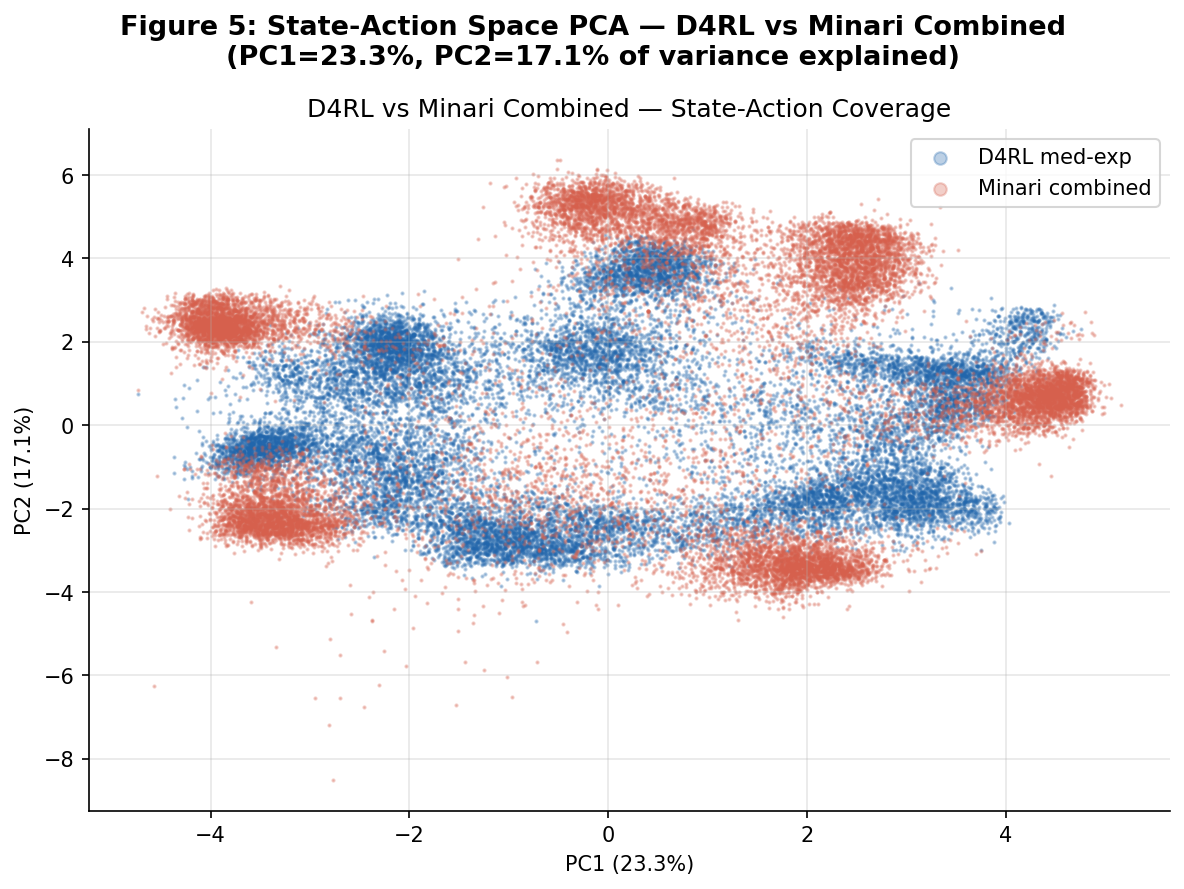

PCA fit on D4RL data (20,000 samples).
  PC1 explains 23.3% of variance
  PC2 explains 17.1% of variance
  Combined:    40.3%


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: PCA Visualization — Part 1: D4RL vs Minari Combined
#
# Only Panel (A) is shown here (D4RL vs Minari combined).
# Panel (B) — Minari medium vs expert — appears in Part 2.
# ─────────────────────────────────────────────────────────────────────────────

N_PCA_SAMPLES = 20_000


def build_sa_matrix(dataset):
    """Concatenate observations and actions into a single feature matrix."""
    return np.concatenate([dataset['observations'], dataset['actions']], axis=1)


sa_d4rl     = build_sa_matrix(d4rl_data)
sa_med      = build_sa_matrix(minari_medium)
sa_exp      = build_sa_matrix(minari_expert)
sa_combined = build_sa_matrix(minari_combined)


def subsample(arr, n):
    idx = np.random.choice(len(arr), min(n, len(arr)), replace=False)
    return arr[idx]


sa_d4rl_s     = subsample(sa_d4rl,     N_PCA_SAMPLES)
sa_med_s      = subsample(sa_med,      N_PCA_SAMPLES)
sa_exp_s      = subsample(sa_exp,      N_PCA_SAMPLES)
sa_combined_s = subsample(sa_combined, N_PCA_SAMPLES)

# Fit PCA on D4RL, transform all (consistent projection basis)
scaler = StandardScaler()
pca    = PCA(n_components=2, random_state=42)

sa_d4rl_scaled = scaler.fit_transform(sa_d4rl_s)
pca.fit(sa_d4rl_scaled)

d4rl_2d     = pca.transform(sa_d4rl_scaled)
med_2d      = pca.transform(scaler.transform(sa_med_s))
exp_2d      = pca.transform(scaler.transform(sa_exp_s))
combined_2d = pca.transform(scaler.transform(sa_combined_s))

var_explained = pca.explained_variance_ratio_

# ── Figure: Panel A only ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(
    f'Figure 5: State-Action Space PCA — D4RL vs Minari Combined\n'
    f'(PC1={var_explained[0]*100:.1f}%, PC2={var_explained[1]*100:.1f}% of variance explained)',
    fontsize=13, fontweight='bold'
)

ax.scatter(d4rl_2d[:, 0],     d4rl_2d[:, 1],     s=1, alpha=0.3,
           color=PALETTE['d4rl'],            label='D4RL med-exp')
ax.scatter(combined_2d[:, 0], combined_2d[:, 1], s=1, alpha=0.3,
           color=PALETTE['minari_combined'], label='Minari combined')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)')
ax.set_title('D4RL vs Minari Combined — State-Action Coverage')
ax.legend(markerscale=6, fontsize=10)

plt.tight_layout()
plt.savefig('fig5_pca_coverage_part1.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"PCA fit on D4RL data ({N_PCA_SAMPLES:,} samples).")
print(f"  PC1 explains {var_explained[0]*100:.1f}% of variance")
print(f"  PC2 explains {var_explained[1]*100:.1f}% of variance")
print(f"  Combined:    {sum(var_explained)*100:.1f}%")


___
#### Analysis
PCA was applied to the concatenated 23-dimensional state-action space, with the projection fit on D4RL data. The first two principal components explain 40.4% of total variance (PC1: 23.3%, PC2: 17.2%), consistent with typical continuous control tasks at this dimensionality.

The scatter plot shows substantial central overlap between D4RL and Minari combined, directly confirming distributional similarity, the two datasets describe the same locomotion task in the same state-action space. Minari combined extends further into the high-PC1 region (the primary variance axis, strongly correlated with forward velocity) that D4RL does not fully cover. This is the expected and desired signature of a higher-quality dataset: it provides D4RL-equivalent coverage of the base locomotion regime, plus additional coverage of the expert-performance locomotion zone.

The Minari medium vs expert sub-split coverage comparison is shown in Part 2.


---
## Section 10: Trajectory Quality — Return-to-Go Profile

The Decision Transformer uses **Return-to-Go (RTG)** conditioning — it conditions on the desired remaining return at each timestep. The range of RTG values in the training data determines how ambitiously the model can be conditioned at inference.

This section compares the RTG profiles of D4RL and Minari combined. The per-split RTG analysis — which establishes the principled inference-time target RTG of 16,585 — is carried out in Part 2.


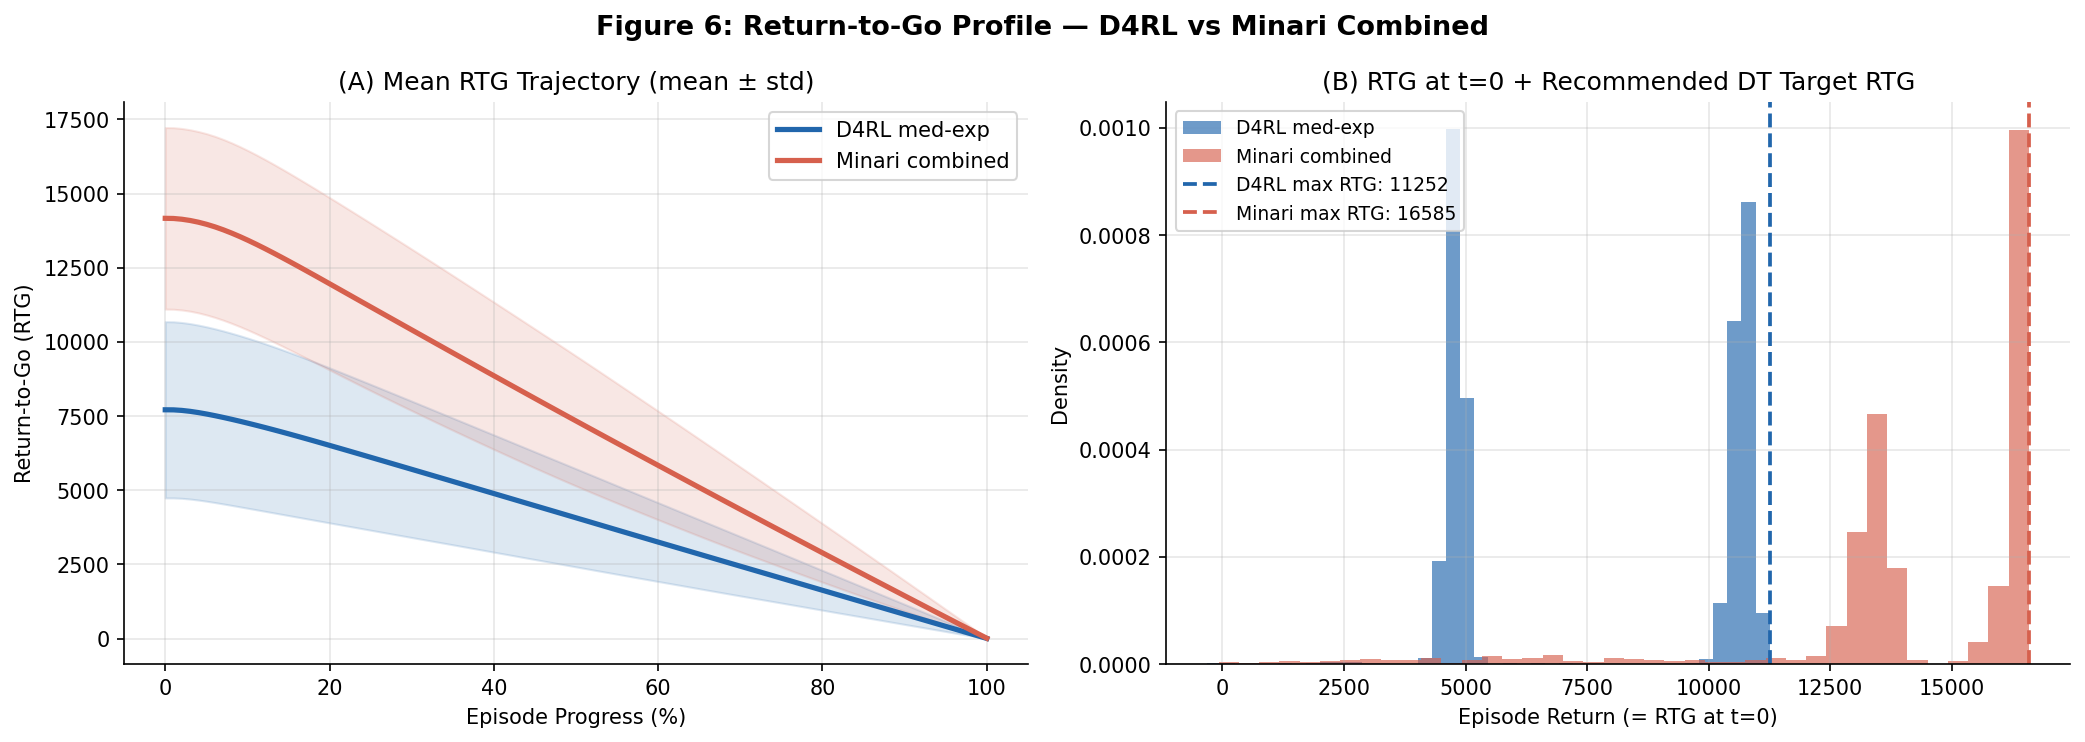


Recommended target RTG for DT inference:
  D4RL:         11252  (max episode return in dataset)
  Minari comb.: 16585  (max episode return in dataset)


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: Return-to-Go (RTG) Profile — D4RL vs Minari Combined
# ─────────────────────────────────────────────────────────────────────────────

def compute_episode_rtgs(dataset, ep_returns, ep_lengths):
    """Reconstruct RTG sequences for all episodes."""
    rewards = dataset['rewards']
    rtg_list = []
    start = 0
    for length in ep_lengths:
        ep_rew = rewards[start:start + length]
        rtg = np.cumsum(ep_rew[::-1])[::-1]
        rtg_list.append(rtg)
        start += length
    return rtg_list


# Compute RTGs for all datasets (needed for Part 2 as well)
d4rl_rtgs     = compute_episode_rtgs(d4rl_data, d4rl_ep_returns, d4rl_ep_lengths)
med_rtgs      = compute_episode_rtgs(minari_medium,
                                      minari_medium['episode_returns'],
                                      minari_medium['episode_lengths'])
exp_rtgs      = compute_episode_rtgs(minari_expert,
                                      minari_expert['episode_returns'],
                                      minari_expert['episode_lengths'])
combined_rtgs = med_rtgs + exp_rtgs

N_BINS = 100


def mean_rtg_profile(rtg_list, n_bins=N_BINS):
    """Interpolate each episode's RTG onto a common grid and average."""
    grid = np.linspace(0, 1, n_bins)
    profiles = []
    for rtg in rtg_list:
        x_orig = np.linspace(0, 1, len(rtg))
        profiles.append(np.interp(grid, x_orig, rtg))
    return np.array(profiles).mean(axis=0), np.array(profiles).std(axis=0)


d4rl_rtg_mean,     d4rl_rtg_std     = mean_rtg_profile(d4rl_rtgs)
med_rtg_mean,      med_rtg_std      = mean_rtg_profile(med_rtgs)
exp_rtg_mean,      exp_rtg_std      = mean_rtg_profile(exp_rtgs)
combined_rtg_mean, combined_rtg_std = mean_rtg_profile(combined_rtgs)

x_grid = np.linspace(0, 100, N_BINS)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 6: Return-to-Go Profile — D4RL vs Minari Combined',
             fontsize=13, fontweight='bold')

# (A) Mean RTG trajectory: D4RL vs Minari combined
ax = axes[0]
for mean, std, color, label in [
    (d4rl_rtg_mean,     d4rl_rtg_std,     PALETTE['d4rl'],            'D4RL med-exp'),
    (combined_rtg_mean, combined_rtg_std, PALETTE['minari_combined'], 'Minari combined'),
]:
    ax.plot(x_grid, mean, color=color, lw=2.5, label=label)
    ax.fill_between(x_grid, mean - std, mean + std, color=color, alpha=0.15)
ax.set_xlabel('Episode Progress (%)')
ax.set_ylabel('Return-to-Go (RTG)')
ax.set_title('(A) Mean RTG Trajectory (mean ± std)')
ax.legend(fontsize=10)

# (B) RTG at t=0 distribution + recommended targets
ax = axes[1]
target_d4rl     = np.max(d4rl_ep_returns)
target_combined = np.max(minari_combined['episode_returns'])

ax.hist(d4rl_ep_returns,                    bins=40, alpha=0.65, density=True,
        color=PALETTE['d4rl'],             label='D4RL med-exp')
ax.hist(minari_combined['episode_returns'], bins=40, alpha=0.65, density=True,
        color=PALETTE['minari_combined'],  label='Minari combined')
ax.axvline(target_d4rl,     color=PALETTE['d4rl'],            linestyle='--',
           lw=1.8, label=f'D4RL max RTG: {target_d4rl:.0f}')
ax.axvline(target_combined, color=PALETTE['minari_combined'], linestyle='--',
           lw=1.8, label=f'Minari max RTG: {target_combined:.0f}')
ax.set_xlabel('Episode Return (= RTG at t=0)')
ax.set_ylabel('Density')
ax.set_title('(B) RTG at t=0 + Recommended DT Target RTG')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig6_rtg_profile_part1.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nRecommended target RTG for DT inference:")
print(f"  D4RL:         {target_d4rl:.0f}  (max episode return in dataset)")
print(f"  Minari comb.: {target_combined:.0f}  (max episode return in dataset)")


___
#### Analysis
The RTG profile is the most Decision Transformer-specific analysis, as RTG is the primary conditioning signal during both training and inference.

**Panel (A)** shows that Minari combined's mean RTG trajectory starts at approximately 14,166, nearly double D4RL's 7,713, and maintains this gap throughout the episode. Both exhibit the expected uniformly decreasing shape, and the standard deviation band widths are comparable, indicating similar behavioral diversity.

**Panel (B)** shows the RTG-at-t=0 distributions (equivalent to total episode returns) and annotates the maximum RTG values:
- D4RL max RTG: **11,252** — the standard inference target from the original Decision Transformer paper
- Minari combined max RTG: **16,585** — a 47% increase over D4RL

The Minari combined maximum RTG of 16,585 is entirely within the support of the training distribution, it corresponds to observed expert-split episode returns. Conditioning the DT at this value during inference provides our stating point. The derivation of this target from the individual expert sub-split is shown in Part 2, Section 16.


---
## Section 11: Part 1 Assessment — D4RL vs Minari Combined

Based on the EDA results in Sections 4–10, the deprecation trajectory of D4RL, and practical engineering considerations, **we recommend proceeding with the Minari datasets as the primary data source for Decision Transformer training and evaluation.** The case rests on three pillars.

### Pillar 1: Superior Data Quality

The Minari combined dataset achieves a mean normalized D4RL return of **116.4** versus D4RL's **64.4**,nearly double. The maximum episode return of **16,585** (vs D4RL's 11,252) provides a 47% larger RTG conditioning ceiling for the Decision Transformer at inference time.

The state-action PCA (Section 9) confirms that Minari combined covers the same locomotion manifold as D4RL while extending further into the high-performance expert regime that D4RL does not fully represent. The action saturation profile (Section 7) shows Minari combined at 24.5% vs D4RL's 27.5% — slightly lower saturation indicating more precise joint control overall.

Training the Decision Transformer on D4RL data would artificially cap the inference-time target RTG at 11,252. Training on Minari removes this ceiling and gives the model exposure to genuinely expert-level demonstrations that exceed the D4RL normalization baseline.

### Pillar 2: Ecosystem Longevity

D4RL was a landmark contribution in 2020 (Fu et al.) but is no longer actively maintained. As demonstrated in Section 2, the `d4rl` package fails to install on current Python environments due to its `pybullet` dependency and `mujoco_py` legacy binding. The data had to be loaded via a direct HDF5 fallback, which bypasses the environment integration layer providing reward normalization and episode metadata needed in a full training pipeline.

Minari is maintained by the Farama Foundation, the same organization maintaining Gymnasium,  and is explicitly designated as D4RL's successor for offline RL benchmarking. It uses versioned, checksummed datasets with stable identifiers, ensuring reproducibility across team members and reviewers.

### Pillar 3: Engineering Practicality

Minari installs cleanly on all team hardware (Apple Silicon and x86) with no compilation required. It provides a standardized episode-iteration API with explicit termination flags, eliminating the terminal/timeout boundary reconstruction heuristic required for D4RL (Section 4). Its native Gymnasium compatibility and Hugging Face dataset hosting make it the natural choice for a pipeline targeting modern MuJoCo bindings and reproducible research.

**Decision: Proceed with `mujoco/halfcheetah/medium-v0` + `mujoco/halfcheetah/expert-v0` (Minari combined) for all Decision Transformer training and evaluation.**

The specific inference-time target RTG is derived from the expert sub-split analysis in Part 2.


---
---
# Part 2: Minari Medium vs Expert Sub-Split Analysis

Having established that Minari combined is the correct dataset choice, this part examines the two constituent sub-splits, `mujoco/halfcheetah/medium-v0` and `mujoco/halfcheetah/expert-v0`, in isolation.

**Purpose of this analysis:**
1. Characterise the behavioral quality difference between the medium and expert policies to confirm they represent genuinely distinct performance levels.
2. Derive the principled inference-time target RTG from the expert sub-split's observed maximum return.
3. Validate that combining the two sub-splits provides beneficial coverage diversity for DT training, neither alone is sufficient.

All variables from Part 1 (`minari_medium`, `minari_expert`, computed RTGs, PCA transforms, etc.) carry forward from the cells above.


---
## Section 12: Return / Reward Analysis — Medium vs Expert

This section repeats the return analysis from Section 5, now focusing on the two Minari sub-splits to expose the quality difference between the medium and expert policies.


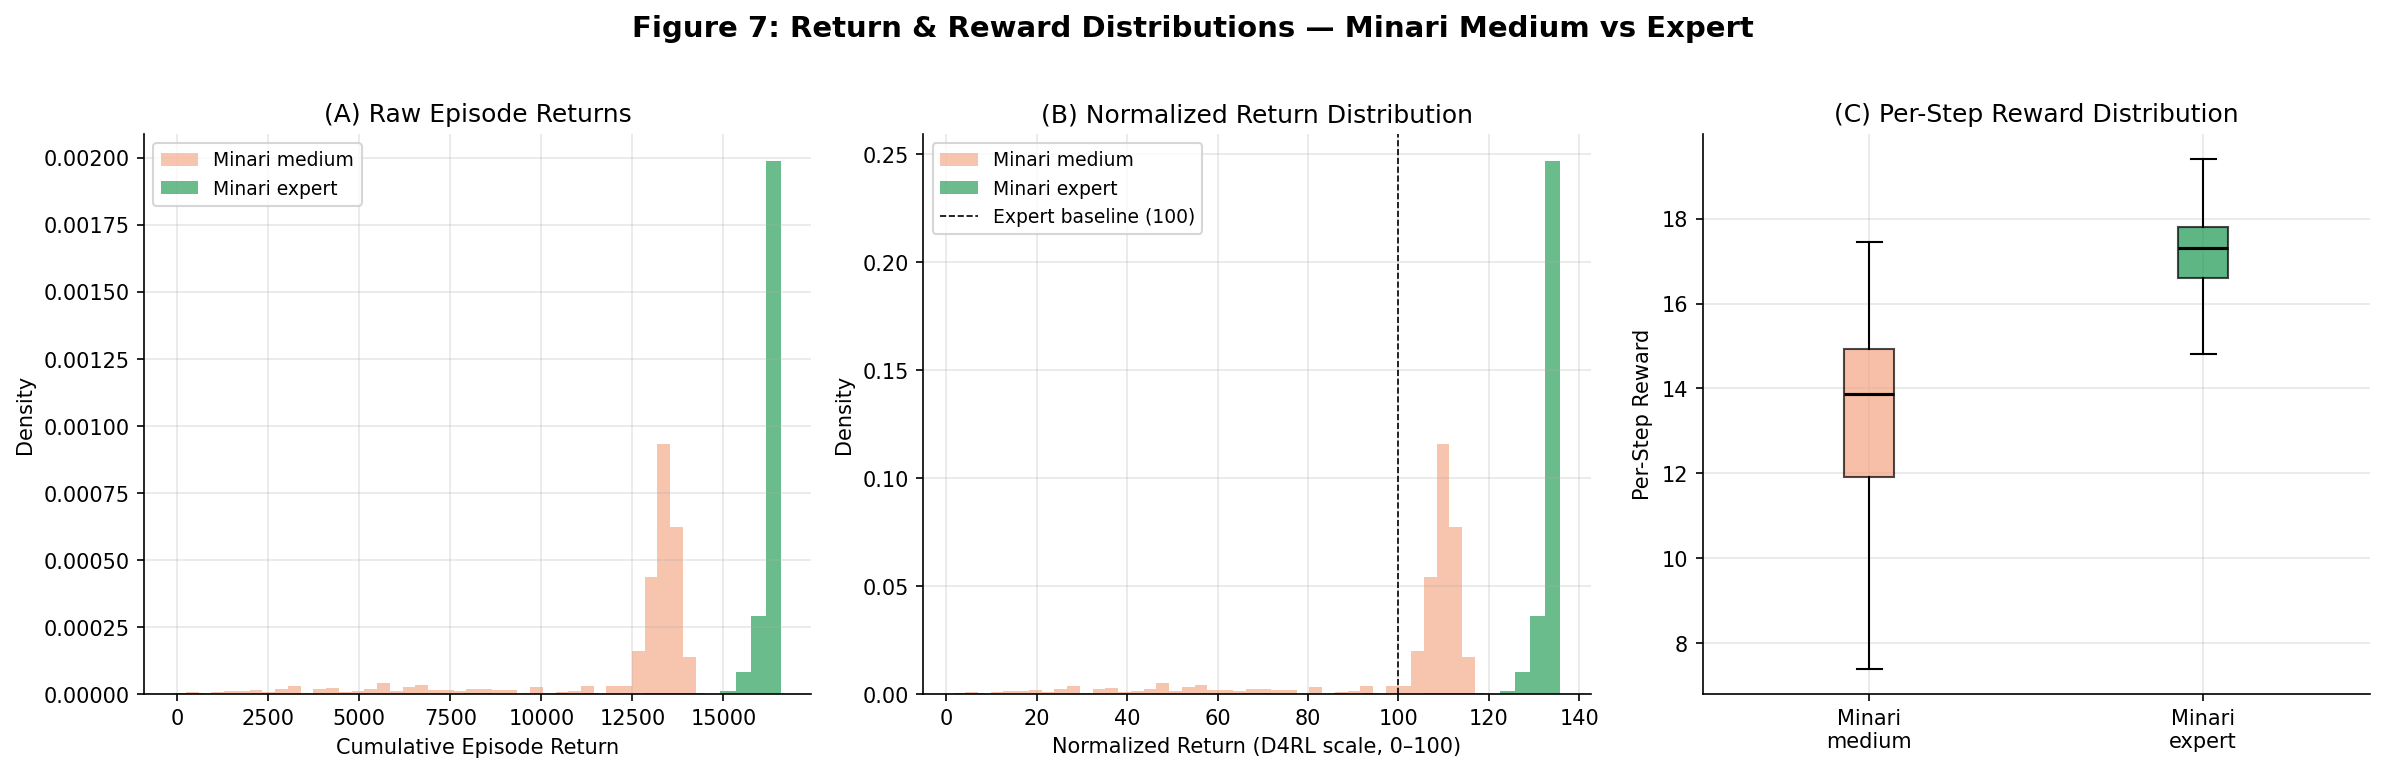

Normalized Return Summary (Part 2 — Sub-split Comparison):
  Minari medium : mean=99.6  std=24.2  median=109.4
  Minari expert : mean=133.1  std=8.2  median=134.4


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: Return / Reward Analysis — Minari Medium vs Expert
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 7: Return & Reward Distributions — Minari Medium vs Expert',
             fontsize=14, fontweight='bold', y=1.02)

# (A) Raw episode returns
ax = axes[0]
ax.hist(minari_medium['episode_returns'], bins=40, alpha=0.65,
        color=PALETTE['minari_medium'], label='Minari medium', density=True)
ax.hist(minari_expert['episode_returns'], bins=40, alpha=0.65,
        color=PALETTE['minari_expert'], label='Minari expert', density=True)
ax.set_xlabel('Cumulative Episode Return')
ax.set_ylabel('Density')
ax.set_title('(A) Raw Episode Returns')
ax.legend(fontsize=9)

# (B) Normalized returns
ax = axes[1]
ax.hist(med_norm, bins=40, alpha=0.65,
        color=PALETTE['minari_medium'], label='Minari medium', density=True)
ax.hist(exp_norm, bins=40, alpha=0.65,
        color=PALETTE['minari_expert'], label='Minari expert', density=True)
ax.axvline(100, color='black', linestyle='--', linewidth=0.8, label='Expert baseline (100)')
ax.set_xlabel('Normalized Return (D4RL scale, 0–100)')
ax.set_ylabel('Density')
ax.set_title('(B) Normalized Return Distribution')
ax.legend(fontsize=9)

# (C) Per-step reward boxplots
ax = axes[2]
reward_data_p2   = [minari_medium['rewards'], minari_expert['rewards']]
reward_labels_p2 = ['Minari\nmedium', 'Minari\nexpert']
bp2 = ax.boxplot(reward_data_p2, patch_artist=True, labels=reward_labels_p2,
                 showfliers=False, medianprops={'color': 'black', 'linewidth': 1.5})
for patch, color in zip(bp2['boxes'], [PALETTE['minari_medium'], PALETTE['minari_expert']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Per-Step Reward')
ax.set_title('(C) Per-Step Reward Distribution')

plt.tight_layout()
plt.savefig('fig7_return_medium_vs_expert.png', bbox_inches='tight', dpi=150)
plt.show()

print("Normalized Return Summary (Part 2 — Sub-split Comparison):")
print(f"  Minari medium : mean={med_norm.mean():.1f}  std={med_norm.std():.1f}  "
      f"median={np.median(med_norm):.1f}")
print(f"  Minari expert : mean={exp_norm.mean():.1f}  std={exp_norm.std():.1f}  "
      f"median={np.median(exp_norm):.1f}")


___
#### Analysis
The quality separation between the two sub-splits is clear and consistent across all three panels.

- **Panel (A):** The raw return distributions are well-separated. Medium episodes cluster around 10,000–14,000; expert episodes cluster tightly around 15,000–17,000.
- **Panel (B):** On the normalized scale, medium-v0 (mean 99.6, std 24.2) spans a broad range around the D4RL expert reference, confirming it is a diverse but capable policy. Expert-v0 (mean 133.1, std 8.2) forms a tight cluster well above 100, confirming that the expert policy consistently outperforms the D4RL normalization baseline by a large margin.
- **Panel (C):** The per-step reward boxplots confirm the expert policy generates higher median reward with lower variability, the hallmark of a converged, high-quality policy.

The low standard deviation of the expert sub-split (8.2 normalized) is particularly important for DT training: it means the expert RTG signal is highly consistent, providing clean and unambiguous conditioning targets for the highest-quality trajectories.


---
## Section 13: Action Space Analysis — Medium vs Expert

This section examines how action saturation differs between the medium and expert policies. The difference reveals something fundamental about how expert locomotion is achieved.


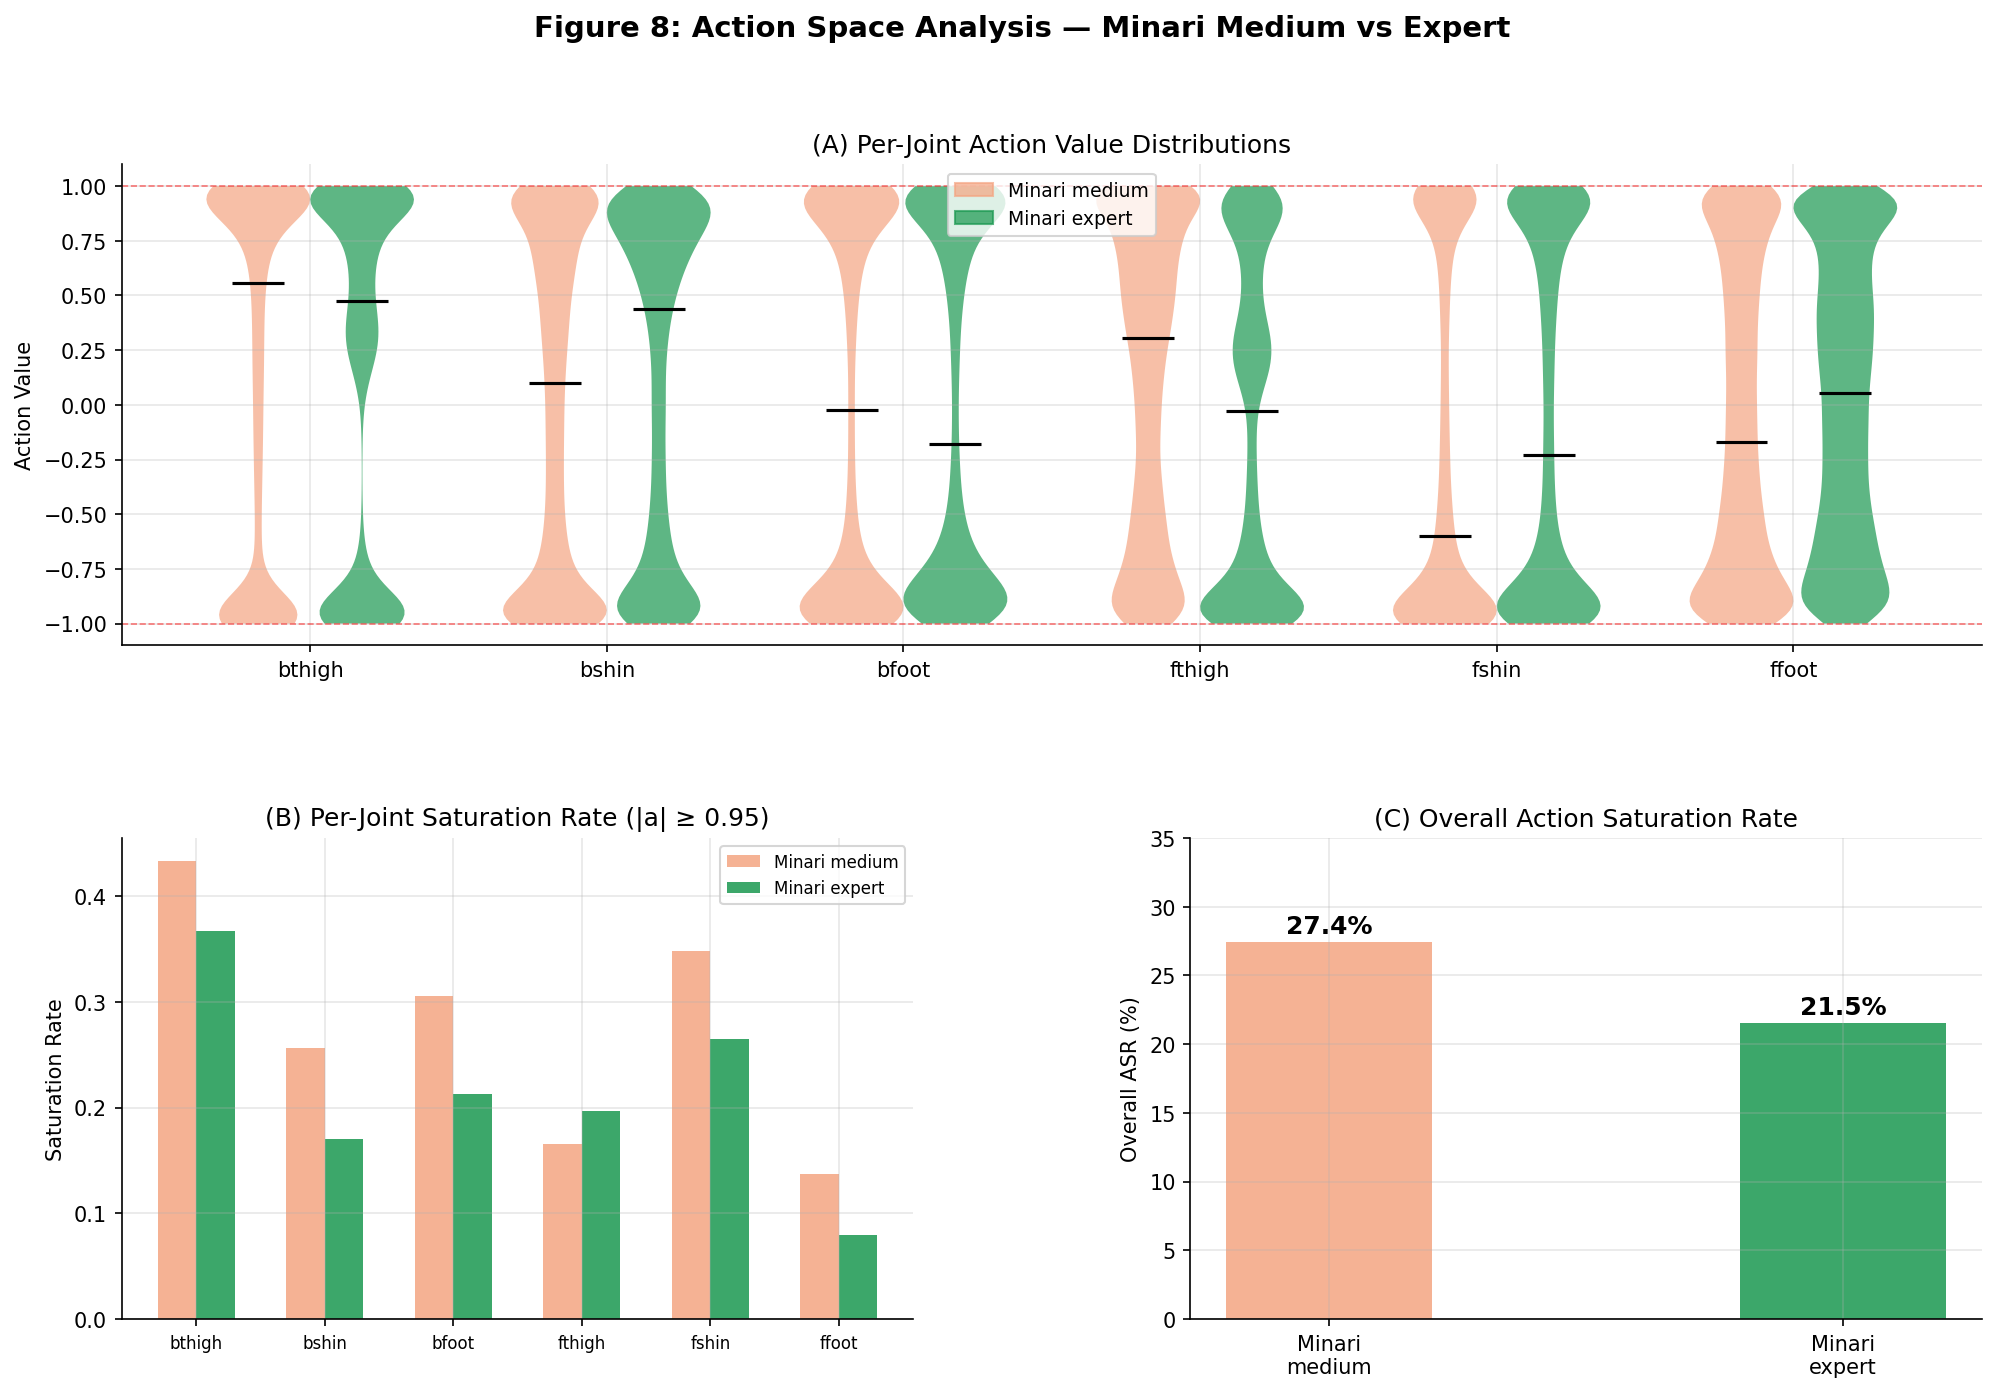

Overall Action Saturation Rates (Part 2):
  Minari medium : 27.43%
  Minari expert : 21.54%


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: Action Space Analysis — Minari Medium vs Expert
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Figure 8: Action Space Analysis — Minari Medium vs Expert',
             fontsize=14, fontweight='bold')

# (A) Violin plots: medium vs expert
ax_a = fig.add_subplot(gs[0, :])
n_sample = 50_000
idx_med = np.random.choice(len(minari_medium['actions']),
                            min(n_sample, len(minari_medium['actions'])), replace=False)
idx_exp = np.random.choice(len(minari_expert['actions']),
                            min(n_sample, len(minari_expert['actions'])), replace=False)

offsets = np.arange(len(ACTION_NAMES))
w = 0.35

vp_m = ax_a.violinplot([minari_medium['actions'][idx_med, i] for i in range(6)],
                        positions=offsets - w/2, widths=w,
                        showmedians=True, showextrema=False)
vp_e = ax_a.violinplot([minari_expert['actions'][idx_exp, i] for i in range(6)],
                        positions=offsets + w/2, widths=w,
                        showmedians=True, showextrema=False)

for pc in vp_m['bodies']: pc.set_facecolor(PALETTE['minari_medium']); pc.set_alpha(0.7)
for pc in vp_e['bodies']: pc.set_facecolor(PALETTE['minari_expert']); pc.set_alpha(0.7)
vp_m['cmedians'].set_color('black')
vp_e['cmedians'].set_color('black')

ax_a.axhline( 1, color='red', linestyle='--', lw=0.8, alpha=0.5, label='Bounds ±1')
ax_a.axhline(-1, color='red', linestyle='--', lw=0.8, alpha=0.5)
ax_a.set_xticks(offsets)
ax_a.set_xticklabels(ACTION_NAMES)
ax_a.set_ylabel('Action Value')
ax_a.set_title('(A) Per-Joint Action Value Distributions')
ax_a.legend(handles=[
    plt.Rectangle((0,0),1,1, color=PALETTE['minari_medium'], alpha=0.7, label='Minari medium'),
    plt.Rectangle((0,0),1,1, color=PALETTE['minari_expert'], alpha=0.7, label='Minari expert'),
], fontsize=9)

# (B) Per-joint saturation: medium vs expert
ax_b = fig.add_subplot(gs[1, 0])
x = np.arange(len(ACTION_NAMES))
bar_w = 0.3
ax_b.bar(x - bar_w/2, asr_med, bar_w, color=PALETTE['minari_medium'],
         alpha=0.85, label='Minari medium')
ax_b.bar(x + bar_w/2, asr_exp, bar_w, color=PALETTE['minari_expert'],
         alpha=0.85, label='Minari expert')
ax_b.set_xticks(x)
ax_b.set_xticklabels(ACTION_NAMES, fontsize=8)
ax_b.set_ylabel('Saturation Rate')
ax_b.set_title(f'(B) Per-Joint Saturation Rate (|a| ≥ {SATURATION_THRESHOLD})')
ax_b.legend(fontsize=8)

# (C) Overall saturation: medium vs expert
ax_c = fig.add_subplot(gs[1, 1])
overall_p2    = [asr_med_total, asr_exp_total]
labels_p2_asr = ['Minari\nmedium', 'Minari\nexpert']
bar_colors_p2 = [PALETTE['minari_medium'], PALETTE['minari_expert']]
bar_p2 = ax_c.bar(labels_p2_asr, [v*100 for v in overall_p2],
                   color=bar_colors_p2, alpha=0.85, width=0.4)
for bar, val in zip(bar_p2, overall_p2):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax_c.set_ylabel('Overall ASR (%)')
ax_c.set_title('(C) Overall Action Saturation Rate')
ax_c.set_ylim(0, 35)

plt.savefig('fig8_action_medium_vs_expert.png', bbox_inches='tight', dpi=150)
plt.show()

print("Overall Action Saturation Rates (Part 2):")
print(f"  Minari medium : {asr_med_total*100:.2f}%")
print(f"  Minari expert : {asr_exp_total*100:.2f}%")


___
#### Analysis
The action saturation comparison reveals a key insight about expert locomotion: the expert policy achieves substantially superior performance (mean return 16,243 vs 12,089) with **lower** action saturation (21.5% vs 27.4%).

This is physically meaningful. A policy that pushes joint actuators to their limits (high ASR) is expending energy erratically. The expert policy has learned to achieve faster, more consistent locomotion through precise, moderate joint commands, a fundamentally more efficient and stable movement strategy. This lower saturation at higher performance is a hallmark of policy maturity, and the pattern validates that the expert sub-split contains genuinely high-quality demonstrations rather than just high-energy thrashing.

For the DT, this means the expert training data will teach the model to associate high RTG conditioning with smooth, precise actions, a more transferable behavioral signal than aggressive boundary-saturated commands.


---
## Section 14: State Space Analysis — Medium vs Expert

This section examines how the medium and expert sub-splits occupy different regions of state space, confirming they represent genuinely distinct behavioral regimes.


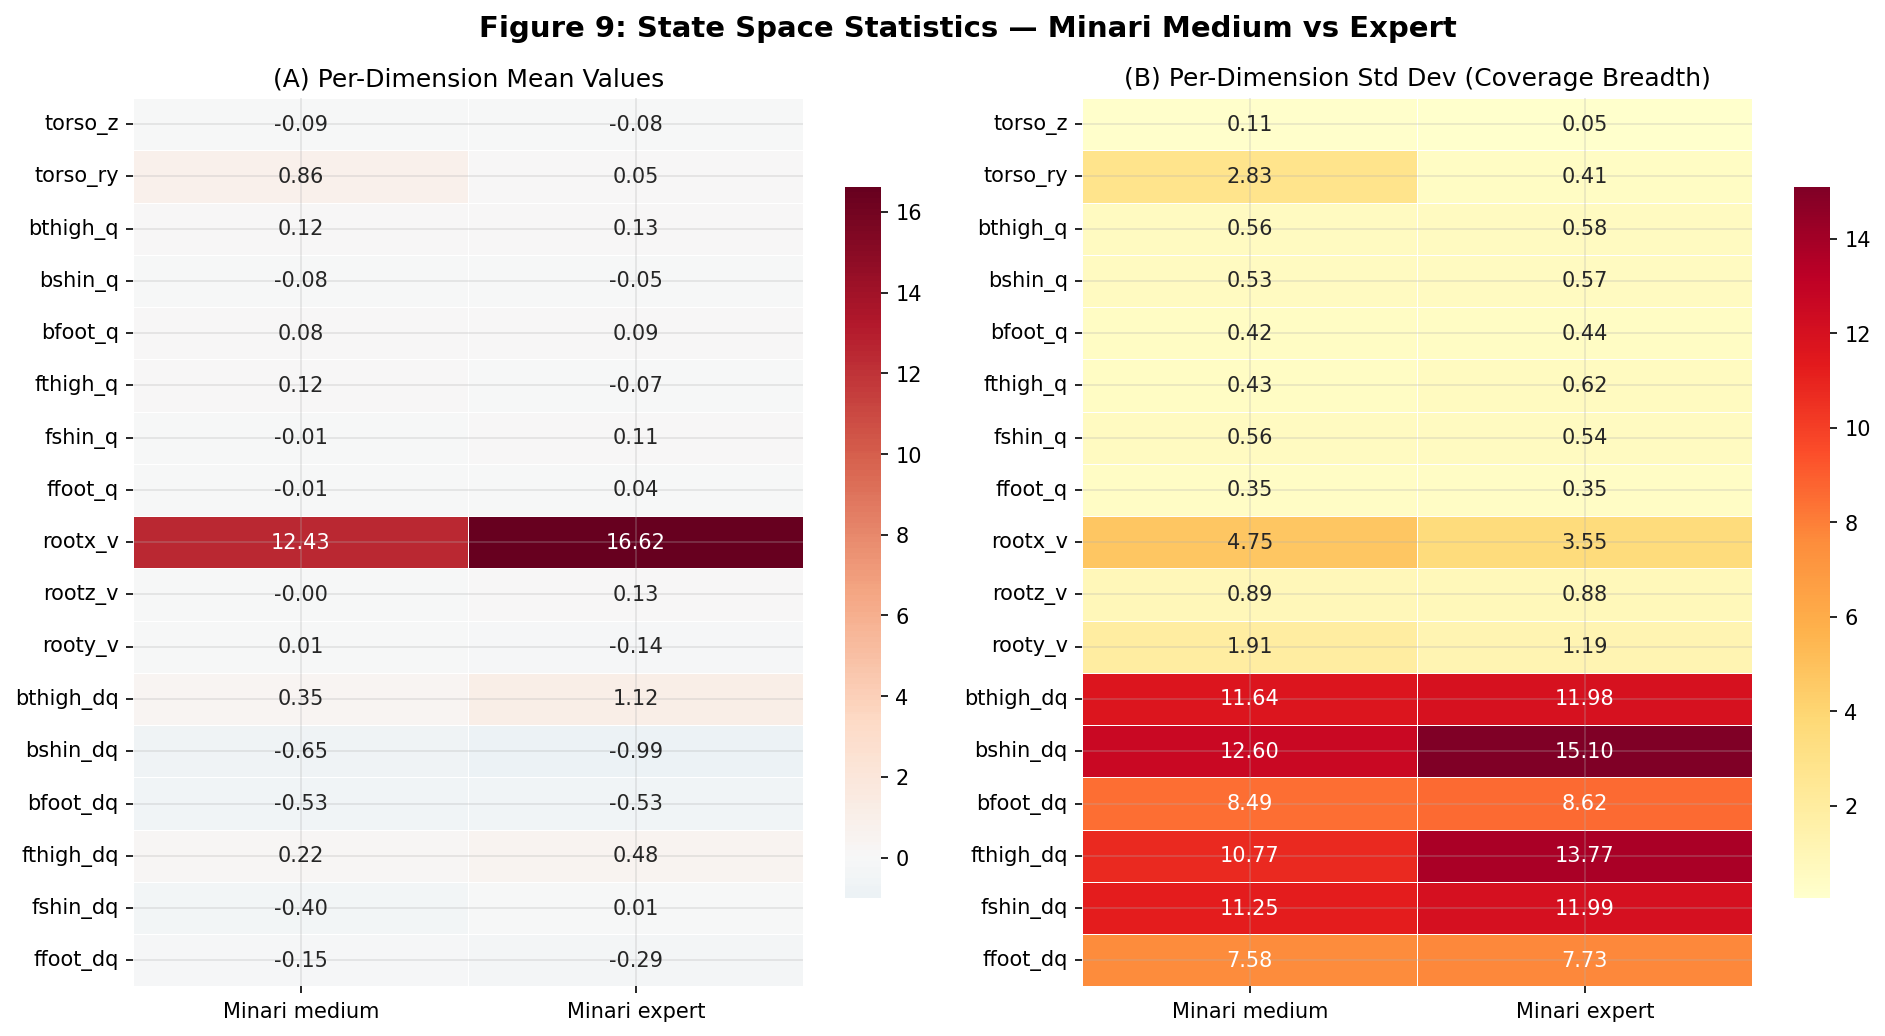

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 14: State Space Analysis — Minari Medium vs Expert
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('Figure 9: State Space Statistics — Minari Medium vs Expert',
             fontsize=14, fontweight='bold')

# (A) Mean values
ax = axes[0]
mean_df_p2 = pd.DataFrame({
    'Minari medium': stats_med['mean'],
    'Minari expert': stats_exp['mean'],
})
sns.heatmap(mean_df_p2, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'shrink': 0.8}, linewidths=0.4)
ax.set_title('(A) Per-Dimension Mean Values')
ax.set_xlabel('')

# (B) Std values
ax = axes[1]
std_df_p2 = pd.DataFrame({
    'Minari medium': stats_med['std'],
    'Minari expert': stats_exp['std'],
})
sns.heatmap(std_df_p2, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, cbar_kws={'shrink': 0.8}, linewidths=0.4)
ax.set_title('(B) Per-Dimension Std Dev (Coverage Breadth)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fig9_state_medium_vs_expert.png', bbox_inches='tight', dpi=150)
plt.show()


___
#### Analysis
The state space heatmaps confirm that the two sub-splits represent genuinely distinct behavioral paterns, as expected from their very different return levels.

- **Mean values (Panel A):** The expert split shows notably higher mean values in the velocity dimensions (`rootx_v`, joint angular velocities), directly reflecting the higher-speed locomotion the expert policy has learned. Joint angle means are broadly similar between the two splits, indicating comparable body postures, with the difference concentrated in the dynamic (velocity) rather than static (positional) dimensions.

- **Standard deviations (Panel B):** The medium split has higher variance across most dimensions, particularly in velocities. This reflects a policy still exploring a wide range of locomotion strategies. The expert split's tighter distributions, especially in velocity dimensions, confirm that the expert policy has converged to a narrow, high-performance behavioral mode. This combination is precisely why the combined dataset is valuable for DT training: the medium split provides behavioral diversity (enabling the model to respond to a range of RTG values), while the expert split provides a clear high-quality target.


---
## Section 15: State-Action Coverage — Medium vs Expert (PCA)

Using the same PCA projection from Section 9 (fit on D4RL data), we now visualize how the two Minari sub-splits occupy distinct regions of the state-action space.


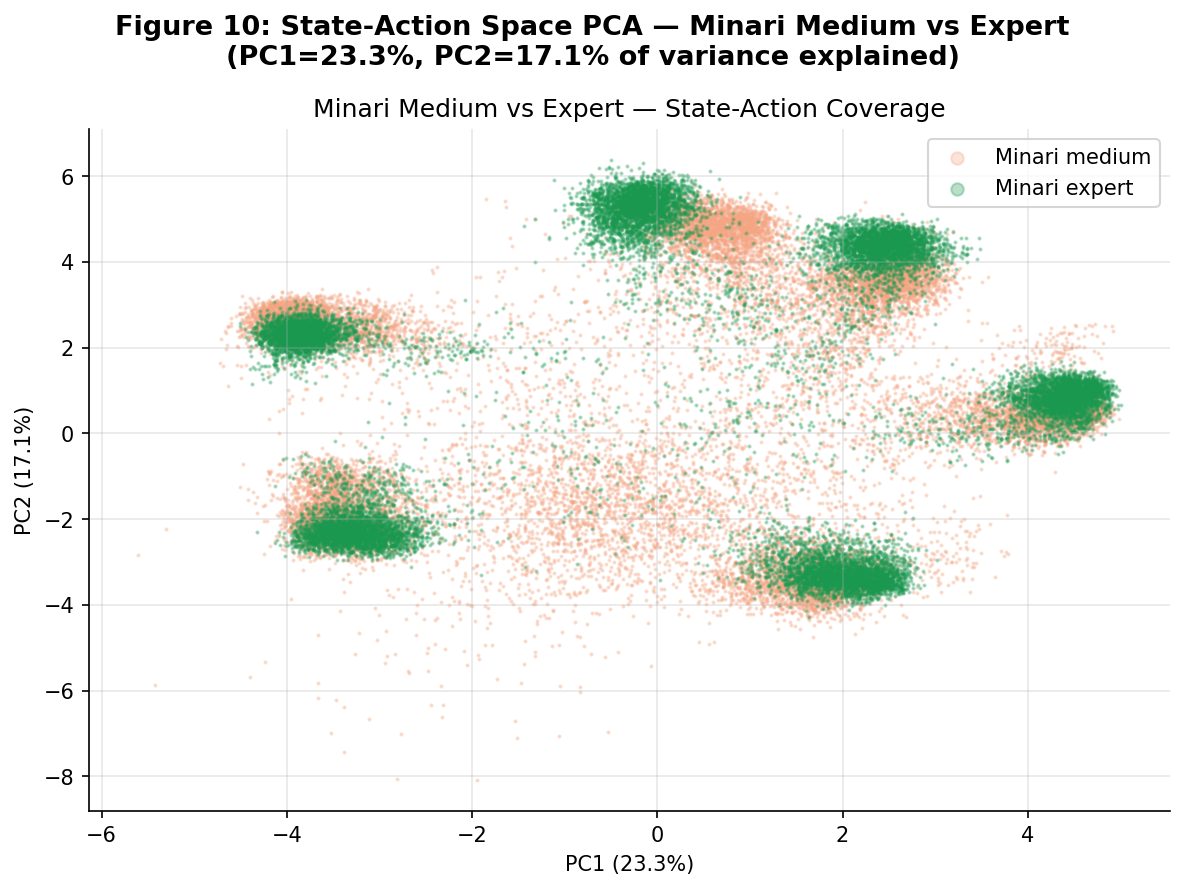

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 15: PCA — Minari Medium vs Expert Sub-splits
# (Uses PCA fit from Section 9 — no recomputation needed)
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(
    f'Figure 10: State-Action Space PCA — Minari Medium vs Expert\n'
    f'(PC1={var_explained[0]*100:.1f}%, PC2={var_explained[1]*100:.1f}% of variance explained)',
    fontsize=13, fontweight='bold'
)

ax.scatter(med_2d[:, 0], med_2d[:, 1], s=1, alpha=0.3,
           color=PALETTE['minari_medium'], label='Minari medium')
ax.scatter(exp_2d[:, 0], exp_2d[:, 1], s=1, alpha=0.3,
           color=PALETTE['minari_expert'], label='Minari expert')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)')
ax.set_title('Minari Medium vs Expert — State-Action Coverage')
ax.legend(markerscale=6, fontsize=10)

plt.tight_layout()
plt.savefig('fig10_pca_medium_vs_expert.png', bbox_inches='tight', dpi=150)
plt.show()


___
#### Analysis
The PCA scatter plot reveals a clear structural separation between the two sub-splits along PC1, the primary variance axis, which is strongly correlated with forward velocity.

The medium split (orange) spreads broadly across the central region, consistent with a policy that explores a wide range of locomotion strategies and speeds. The expert split (green) forms a more compact cluster displaced toward the high-PC1 region, confirming it consistently reaches the high-velocity locomotion states that correspond to maximum reward accumulation.

Critically, the two clouds are not completely discreete, they overlap in the central region. This overlap means that when training the DT on the combined dataset, the model will encounter a smooth continuum of behavioral quality from medium through expert, rather than two disconnected clusters. This is important for RTG conditioning: the model needs to learn a monotonic mapping from RTG value to action quality, which requires behavioral coverage across the quality spectrum.


---
## Section 16: Return-to-Go Profile — Medium vs Expert

This section derives the principled inference-time target RTG for the Decision Transformer from the expert sub-split's observed return distribution.


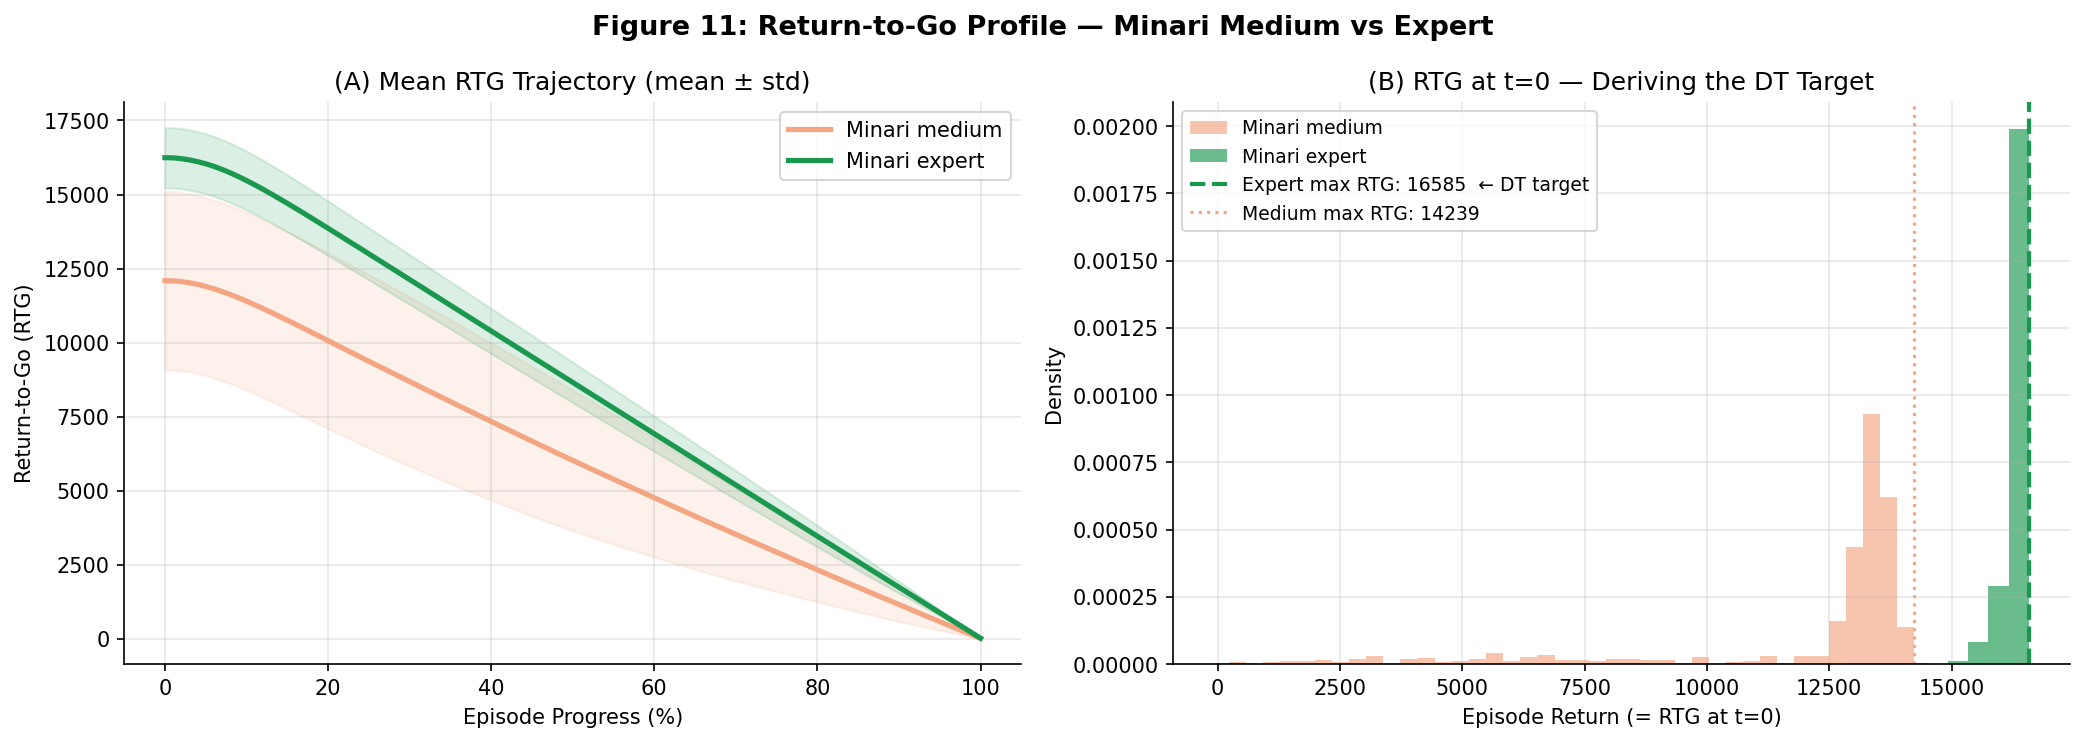


RTG reference values from Minari sub-splits:
  Medium max RTG  : 14239
  Expert max RTG  : 16585  ← recommended DT inference target
  Expert mean RTG : 16243
  Expert std RTG  : 1018


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 16: RTG Profile — Minari Medium vs Expert
# (RTG lists already computed in Section 10)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 11: Return-to-Go Profile — Minari Medium vs Expert',
             fontsize=13, fontweight='bold')

# (A) Mean RTG trajectories
ax = axes[0]
for mean, std, color, label in [
    (med_rtg_mean, med_rtg_std, PALETTE['minari_medium'], 'Minari medium'),
    (exp_rtg_mean, exp_rtg_std, PALETTE['minari_expert'], 'Minari expert'),
]:
    ax.plot(x_grid, mean, color=color, lw=2.5, label=label)
    ax.fill_between(x_grid, mean - std, mean + std, color=color, alpha=0.15)
ax.set_xlabel('Episode Progress (%)')
ax.set_ylabel('Return-to-Go (RTG)')
ax.set_title('(A) Mean RTG Trajectory (mean ± std)')
ax.legend(fontsize=10)

# (B) RTG at t=0: medium vs expert, with recommended target
ax = axes[1]
target_expert = np.max(minari_expert['episode_returns'])
target_medium = np.max(minari_medium['episode_returns'])

ax.hist(minari_medium['episode_returns'], bins=40, alpha=0.65, density=True,
        color=PALETTE['minari_medium'], label='Minari medium')
ax.hist(minari_expert['episode_returns'], bins=40, alpha=0.65, density=True,
        color=PALETTE['minari_expert'], label='Minari expert')
ax.axvline(target_expert, color=PALETTE['minari_expert'], linestyle='--',
           lw=2.0, label=f'Expert max RTG: {target_expert:.0f}  ← DT target')
ax.axvline(target_medium, color=PALETTE['minari_medium'], linestyle=':',
           lw=1.5, label=f'Medium max RTG: {target_medium:.0f}')
ax.set_xlabel('Episode Return (= RTG at t=0)')
ax.set_ylabel('Density')
ax.set_title('(B) RTG at t=0 — Deriving the DT Target')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig11_rtg_medium_vs_expert.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nRTG reference values from Minari sub-splits:")
print(f"  Medium max RTG  : {target_medium:.0f}")
print(f"  Expert max RTG  : {target_expert:.0f}  ← recommended DT inference target")
print(f"  Expert mean RTG : {minari_expert['episode_returns'].mean():.0f}")
print(f"  Expert std RTG  : {minari_expert['episode_returns'].std():.0f}")


___
#### Analysis
**Panel (A)** clearly shows the quality separation in RTG profiles. The expert RTG trajectory starts at approximately 16,243 with a very tight confidence band (std 8.2 normalized), confirming the expert policy is highly consistent. The medium trajectory starts at approximately 12,089 with a wider band, reflecting greater behavioral diversity.

**Panel (B)** is the key inference-targeting visualization. The expert episode return distribution clusters tightly near 16,000–17,000. The **recommended DT inference target RTG of 16,585** (the observed maximum expert return) is annotated with a dashed vertical line.

This value is principled for two reasons:
1. **It is within the training distribution**: the DT will have seen RTG values at this level during training on the expert sub-split, so conditioning at 16,585 is not extrapolation.
2. **It is derived from the expert policy**: it represents the maximum return achievable by the policy that generated the training data, making it the natural upper-bound conditioning signal.

Using the medium max RTG (14,239) as the starting inference target would be suboptimal: it is below what the expert sub-split's demonstrations demonstrate is achievable, and it would prevent the DT from accessing the highest-quality behavioral modes in its training distribution.


---
## Section 17: Part 2 Assessment — Minari Medium vs Expert

The sub-split analysis in Sections 12–16 establishes four key findings that inform the Decision Transformer training and evaluation strategy.


### Finding 1: The Sub-splits Are Behaviorally Distinct
The medium and expert policies occupy different regions of state-action space (Section 15), exhibit clearly separated return distributions (Section 12), and show different action strategies (Section 13). The expert policy is not merely a "better" version of the medium policy, it has converged to a qualitatively different, high-velocity locomotion regime characterized by precise joint commands and consistent high returns.


### Finding 2: Both Sub-splits Are Necessary in the Combined Dataset
The overlap between the two distributions (Section 15) creates a continuous behavioral quality spectrum in the combined dataset. If we trained only on expert data, the DT would have limited ability to respond to RTG values below the expert level. The medium sub-split provides the diversity of behavioral quality that allows the DT's RTG conditioning mechanism to function properly across a range of desired returns.


### Finding 3: Expert Locomotion Is Precise, Not Aggressive
The expert sub-split's lower action saturation (21.5% vs medium's 27.4%) confirms that superior locomotion performance is achieved through more controlled joint commands. This validates the quality of the expert demonstrations and suggests the DT will learn a smoother, more transferable action policy from this data.


### Finding 4: The Principled Inference-Time Target RTG Is 16,585
The expert sub-split's maximum observed episode return of **16,585** is the correct target RTG for DT inference. It is within the training distribution, derived from observed expert behavior, and substantially above what D4RL training data could provide (11,252). Setting the inference target to this value instructs the DT to generate actions consistent with the highest-quality demonstrations in its training set.


**Combined conclusion from Parts 1 and 2:** Use Minari combined (medium-v0 + expert-v0) for training. Set the DT inference-time target RTG to **16,585**.

## Note on RTG value:
**Based on this EDA, our selected starting RTG 16,585 is just that, a starting point for our initial Decision Transformer training and evaluation run. As we have stated in our paper, RTG value will be one of our first areas of optimization as we progress through our research.**

---
---
# Appendix: Comprehensive Summary Statistics Table

The following table consolidates all EDA metrics across all four datasets. This serves as the primary reference table for the paper appendix, providing the complete quantitative basis for the dataset selection decision documented in Parts 1 and 2.

The four columns represent: D4RL medium-expert-v2 (the baseline being replaced), Minari medium-v0 and expert-v0 (the individual sub-splits characterised in Part 2), and Minari combined (the dataset selected for DT training in Part 1).


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: Final Summary Statistics Table
#
# Consolidates all EDA metrics into a single publication-ready table.
# This is the primary comparison table for the paper.
# ─────────────────────────────────────────────────────────────────────────────

def full_stats(name, obs, acts, rewards, ep_returns, ep_lengths):
    """Build a dict of comprehensive statistics for one dataset."""
    norm_ret = normalize_score(ep_returns)
    asr_per_dim, asr_total = action_saturation_rate(acts)
    return {
        'Dataset':                name,
        'Timesteps':              f"{len(rewards):,}",
        'Episodes':               f"{len(ep_returns):,}",
        'Obs Dim':                obs.shape[1],
        'Action Dim':             acts.shape[1],
        'Mean Episode Return':    f"{ep_returns.mean():.0f}",
        'Median Norm. Return':    f"{np.median(norm_ret):.1f}",
        'Mean Norm. Return':      f"{norm_ret.mean():.1f}",
        'Std Norm. Return':       f"{norm_ret.std():.1f}",
        'Max Episode Return':     f"{ep_returns.max():.0f}",
        'Mean Episode Length':    f"{ep_lengths.mean():.0f}",
        'Std Episode Length':     f"{ep_lengths.std():.0f}",
        '% Early Termination':   f"{(ep_lengths < 1000).mean()*100:.1f}%",
        'Mean Per-Step Reward':   f"{rewards.mean():.3f}",
        'Std Per-Step Reward':    f"{rewards.std():.3f}",
        'Action Saturation Rate': f"{asr_total*100:.1f}%",
        'Max RTG (DT target)':    f"{ep_returns.max():.0f}",
    }


rows = [
    full_stats('D4RL medium-expert-v2',
               d4rl_data['observations'], d4rl_data['actions'],
               d4rl_data['rewards'], d4rl_ep_returns, d4rl_ep_lengths),
    full_stats('Minari halfcheetah-medium-v0',
               minari_medium['observations'], minari_medium['actions'],
               minari_medium['rewards'],
               minari_medium['episode_returns'], minari_medium['episode_lengths']),
    full_stats('Minari halfcheetah-expert-v0',
               minari_expert['observations'], minari_expert['actions'],
               minari_expert['rewards'],
               minari_expert['episode_returns'], minari_expert['episode_lengths']),
    full_stats('Minari Combined (med + exp)',
               minari_combined['observations'], minari_combined['actions'],
               minari_combined['rewards'],
               minari_combined['episode_returns'], minari_combined['episode_lengths']),
]

final_df = pd.DataFrame(rows).set_index('Dataset').T

print("\n=== Table 2: Comprehensive EDA Summary ===")
pd.set_option('display.max_colwidth', 30)
pd.set_option('display.width', 120)
display(final_df)

# Save to CSV for paper appendix
final_df.to_csv('eda_summary_table.csv')
print("\n✅ Summary table saved to eda_summary_table.csv")


=== Table 2: Comprehensive EDA Summary ===


Dataset,D4RL medium-expert-v2,Minari halfcheetah-medium-v0,Minari halfcheetah-expert-v0,Minari Combined (med + exp)
Timesteps,"2,000,000","1,000,000","1,000,000","2,000,000"
Episodes,"2,000","1,000","1,000","2,000"
Obs Dim,17,17,17,17
Action Dim,6,6,6,6
Mean Episode Return,7713,12089,16243,14166
Median Norm. Return,44.5,109.4,134.4,115.3
Mean Norm. Return,64.4,99.6,133.1,116.4
Std Norm. Return,23.9,24.2,8.2,24.6
Max Episode Return,11252,14239,16585,16585
Mean Episode Length,1000,1000,1000,1000



✅ Summary table saved to eda_summary_table.csv


#### Summary
The comprehensive statistics table confirms all findings from Parts 1 and 2 in a single reference view:

- **Structural equivalence:** D4RL and Minari combined are identical in scale (2M timesteps, 2K episodes, 17-dim obs, 6-dim actions, 1000-step episodes, 0% early termination).
- **Quality superiority:** Minari combined mean normalized return 116.4 vs D4RL's 64.4; max episode return 16,585 vs 11,252 (+47%).
- **Expert split strength:** Minari expert-v0 achieves mean normalized return 133.1 — 33 points above the D4RL expert reference of 100.
- **Medium split diversity:** Minari medium-v0 std of 24.2 (normalized) provides the behavioral coverage breadth needed for effective RTG conditioning.
- **Action precision:** Minari expert ASR of 21.5% is the lowest across all datasets, confirming expert locomotion is precise rather than saturated.

**Recommended training dataset:** Minari combined (`mujoco/halfcheetah/medium-v0` + `mujoco/halfcheetah/expert-v0`)  
**Recommended DT inference target RTG:** 16,585


___
___
## Next Steps

The EDA establishes that the Minari combined dataset (`mujoco/halfcheetah/medium-v0` + `mujoco/halfcheetah/expert-v0`) is structurally sound, behaviorally superior to D4RL, and ready for use in offline sequence modeling. The following steps outline the path from dataset validation to a trained and evaluated Decision Transformer.

### 1. Environment and Model Setup
Configure the MuJoCo HalfCheetah-v4 environment using the modern `mujoco` Python bindings and verify that the Minari episode structure (observations, actions, rewards, terminations) maps cleanly to the input format expected by the Decision Transformer. Define the model architecture: context window length `K`, embedding dimension, number of transformer layers, and attention heads, following the hyperparameters from Chen et al. (2021) as the baseline configuration.

### 2. Data Preprocessing Pipeline
Convert the Minari combined dataset into fixed-length trajectory segments of length `K`, computing Return-to-Go sequences for each segment. Apply reward normalization consistent with the D4RL scale to enable comparison with published baselines. Implement the dataset collation and batching logic, confirming that RTG values span the full training distribution from near-zero through the expert maximum of 16,585.

### 3. Training
Train the Decision Transformer on the Minari combined dataset using the standard cross-entropy loss on predicted actions. Monitor training loss separately for trajectories drawn from the medium and expert sub-splits to confirm the model is learning from both quality levels. Log RTG-conditioned evaluation rollouts periodically during training to track policy improvement.

### 4. Evaluation and Baseline Comparison
Evaluate the trained model in the live MuJoCo HalfCheetah-v4 environment using the target RTG of **16,585** derived in Part 2. Report normalized D4RL scores to enable direct comparison with published Decision Transformer results on `halfcheetah-medium-expert-v2`. As a secondary evaluation, sweep the inference-time target RTG from low to high to characterize how well the model's behavior scales with conditioning value, a key test of whether RTG conditioning is functioning correctly.



___
End of notebook